# Importing Libraries

In [1]:
! pip install langdetect
import numpy as np
import pandas as pd 
import glob
import json
import seaborn as sns
from tqdm import tqdm
from langdetect import detect
from langdetect import DetectorFactory

import matplotlib.pyplot as plt
plt.style.use('ggplot')


from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import re
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
import nltk
nltk.download('omw-1.4')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer 
lemmatizer = WordNetLemmatizer()


from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from operator import itemgetter
import gensim
from gensim.utils import simple_preprocess
import numpy as np
from collections import Counter
import pprint 

import pyLDAvis
import pyLDAvis.gensim

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import glob
import json
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim.models.nmf import Nmf
from collections import Counter
from operator import itemgetter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import re
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
import nltk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993242 sha256=9ad4ceb158b206454419461d2822138010018d531dba88d4f0b3fef72e001325
  Stored in directory: /root/.cache/pip/wheels/c5/96/8a/f90c59ed25d75e50a8c10a1b1c2d4c402e4dacfa87f3aff36a
Successfully built langdetect


[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/opt/conda/lib/python3.7/site-packages/past/types/oldstr.py:36: DeprecationWarning: invalid escape sequence \d
  """
/opt/conda/lib/python3.7/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload


## Analysis About Top Words After Pre-processing

In [2]:
df = pd.read_csv('/kaggle/input/cord-df/df_10000_processed.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   paper_id          9995 non-null   object
 1   doi               9995 non-null   object
 2   abstract          7108 non-null   object
 3   body_text         9995 non-null   object
 4   authors           9941 non-null   object
 5   title             9995 non-null   object
 6   journal           9340 non-null   object
 7   abstract_summary  9995 non-null   object
 8   language          9995 non-null   object
 9   publish_time      9995 non-null   object
 10  word_count        9995 non-null   int64 
 11  processed_text    9995 non-null   object
dtypes: int64(1), object(11)
memory usage: 937.2+ KB


In [3]:
# Get the top 20 most common words among all the articles
temp_text = df['processed_text']

# split single string in format of "['word1', 'word2', 'word3', ...]" to list of string ['word1' , 'word2', 'word3', ...]
try:
    temp_text = temp_text.apply(lambda x: x[1:-1].split(', '))
    temp_text = temp_text.apply(lambda x: [item[1:-1] for item in x])
except:
    print("already in req. format")
p_text = [item for sublist in temp_text for item in sublist]

df['processed_text'] = temp_text


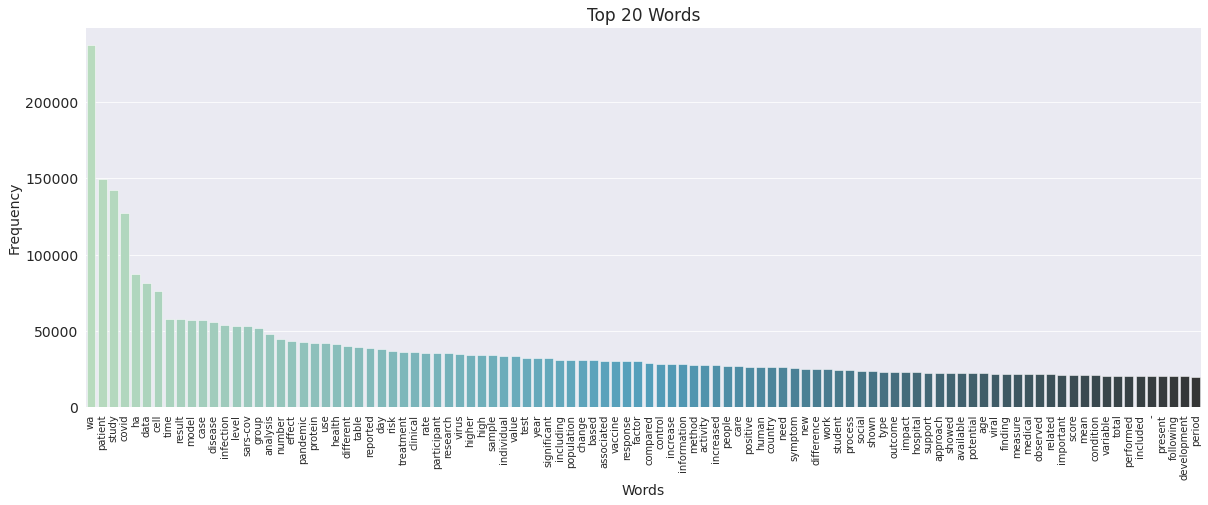

In [4]:

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(100),
    columns=['word', 'frequency']
)

# Plot a bar chart for the top 20 most frequently occuring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=90,
    fontsize=10
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()


## Number of Unique Words...

In [5]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

324401

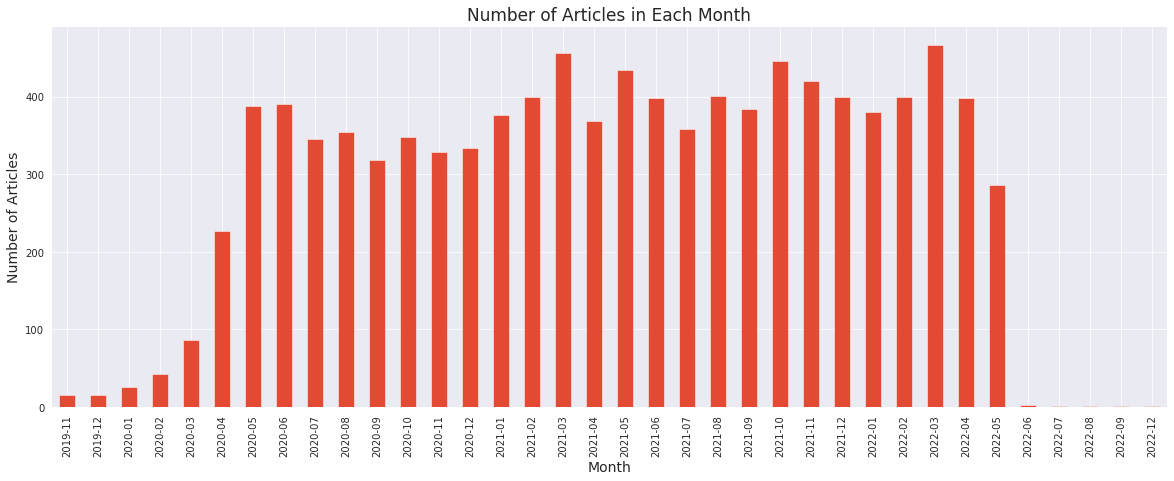

In [6]:
# plot graph for number of articles in each month from november 2019 to december 2022 in bins of 1 month

df_copy = df.copy()
df_copy['publish_time'] = pd.to_datetime(df_copy['publish_time'])
df_copy['publish_time'] = df_copy['publish_time'].dt.to_period('M')
df_copy['publish_time'].value_counts().sort_index().plot(kind='bar', figsize=(20,7))
plt.title('Number of Articles in Each Month', fontsize=17)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)
plt.show()



# Applying Non-Negative Matrix Factorization (NMF) to find Topics

In [7]:
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['month'] = df['publish_time'].dt.month
df['year'] = df['publish_time'].dt.year

In [8]:
df.head()

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,publish_time,word_count,processed_text,month,year
0,e85d5664090aaac23c1714b3d1de71f0b2b882ff,10.1007/s12070-021-02807-2,COVID 19 infections may be associated with a w...,The 2019 novel coronavirus (2019-nCoV) or Seve...,"Desai, Esha J.. Pandya, Achal. Upadhya, Ila...","Epidemiology, Clinical Features and<br>Manage...",Indian J Otolaryngol Head Neck Surg,COVID 19 infections may be associated with a<...,en,2021-08-15,1447,"[novel, coronavirus, ncov, severe_acute_respir...",8,2021
1,5b9e2da60d736bc3b97a54264dab3672cd306e75,10.1111/cen.14540,Background: We sought to evaluate the associat...,States. 4 Many of the abovementioned risk fact...,"Wang, Zhen. Joshi, Avni. Leopold, Kaitlin. ...",Association of vitamin D deficiency with<br>C...,Clin Endocrinol (Oxf),Background: We sought to evaluate the<br>asso...,en,2021-07-12,1430,"[state, abovementioned, risk_factor, modifiabl...",7,2021
2,d3ee272c48f87c9631b2e53c54da884feae32c4a,10.1007/978-3-030-44252-1_2,NaN,historical analysis of the comics selected for...,"Letizia, Angelo J.",Reading Comics for Citizenship,Graphic Novels as Pedagogy in Social Studies,Not provided.,en,2020-04-28,10915,"[historical, analysis, comic, selected, variou...",4,2020
3,90147c26a2ca89ddc175f7bbd591e4991c3b2b54,10.1055/s-0040-1701997,Objectives: Analyze papers published in 2019 w...,Natural Language Processing (NLP) aims at prov...,"Grouin, Cyril. Grabar, Natalia",A Year of Papers Using Biomedical Texts::<br>...,Yearb Med Inform,Objectives: Analyze papers published in 2019<...,en,2020-08-21,2152,"[natural, language, processing, nlp, aim, prov...",8,2020
4,5d1c8d3742ef329635d396f85a127397a691ae88,10.1007/s13304-020-00811-9,"Introduction Recently, Italy has been heavily ...","On the 11th of March, the World Health Organiz...","Pertile, Davide. Gallo, Gaetano. Barra,<br>...",The impact of COVID-19 pandemic on surgical<b...,Updates Surg,"Introduction Recently, Italy has been heavily...",en,2020-06-16,2696,"[th, march, world_health_organization, declare...",6,2020


In [9]:
# make list of dataframes for year 2019
df_nov_2019 = df[(df['month'] == 11) & (df['year'] == 2019)]
df_dec_2019 = df[(df['month'] == 12) & (df['year'] == 2019)]

df_2019 = [ df_nov_2019, df_dec_2019]

# for year 2020
df_jan_2020 = df[(df['month'] == 1) & (df['year'] == 2020)]
df_feb_2020 = df[(df['month'] == 2) & (df['year'] == 2020)]
df_mar_2020 = df[(df['month'] == 3) & (df['year'] == 2020)]
df_apr_2020 = df[(df['month'] == 4) & (df['year'] == 2020)]
df_may_2020 = df[(df['month'] == 5) & (df['year'] == 2020)]
df_jun_2020 = df[(df['month'] == 6) & (df['year'] == 2020)]
df_jul_2020 = df[(df['month'] == 7) & (df['year'] == 2020)]
df_aug_2020 = df[(df['month'] == 8) & (df['year'] == 2020)]
df_sep_2020 = df[(df['month'] == 9) & (df['year'] == 2020)]
df_oct_2020 = df[(df['month'] == 10) & (df['year'] == 2020)]
df_nov_2020 = df[(df['month'] == 11) & (df['year'] == 2020)]
df_dec_2020 = df[(df['month'] == 12) & (df['year'] == 2020)]

df_2020 = [df_jan_2020, df_feb_2020, df_mar_2020, df_apr_2020, df_may_2020, df_jun_2020, 
           df_jul_2020, df_aug_2020, df_sep_2020, df_oct_2020, df_nov_2020, df_dec_2020]


#seperate dataframe for each month of 2021 and add to list
df_jan_2021 = df[(df['month'] == 1) & (df['year'] == 2021)]
df_feb_2021 = df[(df['month'] == 2) & (df['year'] == 2021)]
df_mar_2021 = df[(df['month'] == 3) & (df['year'] == 2021)]
df_apr_2021 = df[(df['month'] == 4) & (df['year'] == 2021)]
df_may_2021 = df[(df['month'] == 5) & (df['year'] == 2021)]
df_jun_2021 = df[(df['month'] == 6) & (df['year'] == 2021)]
df_jul_2021 = df[(df['month'] == 7) & (df['year'] == 2021)]
df_aug_2021 = df[(df['month'] == 8) & (df['year'] == 2021)]
df_sep_2021 = df[(df['month'] == 9) & (df['year'] == 2021)]
df_oct_2021 = df[(df['month'] == 10) & (df['year'] == 2021)]
df_nov_2021 = df[(df['month'] == 11) & (df['year'] == 2021)]
df_dec_2021 = df[(df['month'] == 12) & (df['year'] == 2021)]

df_2021 = [df_jan_2021, df_feb_2021, df_mar_2021, df_apr_2021, df_may_2021, df_jun_2021,
           df_jul_2021, df_aug_2021, df_sep_2021, df_oct_2021, df_nov_2021, df_dec_2021]

# FOr year 2022
df_jan_2022 = df[(df['month'] == 1) & (df['year'] == 2022)]
df_feb_2022 = df[(df['month'] == 2) & (df['year'] == 2022)]
df_mar_2022 = df[(df['month'] == 3) & (df['year'] == 2022)]
df_apr_2022 = df[(df['month'] == 4) & (df['year'] == 2022)]
df_may_2022 = df[(df['month'] == 5) & (df['year'] == 2022)]

df_2022 = [df_jan_2022, df_feb_2022, df_mar_2022, df_apr_2022, df_may_2022]


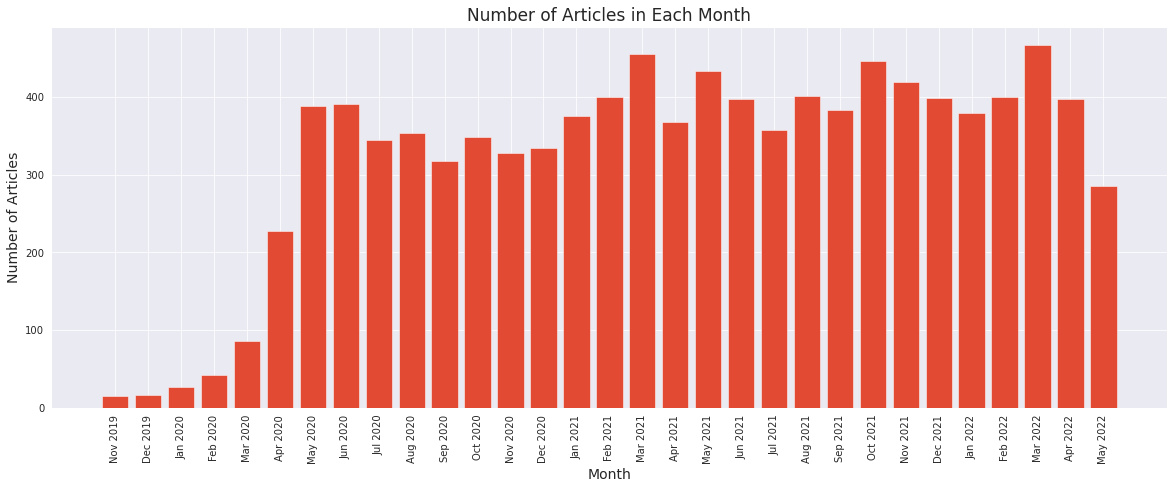

In [10]:
# make list of len df in all months
number_of_articles = []
for i in df_2019:
    number_of_articles.append(len(i))
for i in df_2020:
    number_of_articles.append(len(i))
for i in df_2021:
    number_of_articles.append(len(i))
for i in df_2022:
    number_of_articles.append(len(i))

# make list of months
months = ['Nov 2019', 'Dec 2019', 'Jan 2020', 'Feb 2020', 'Mar 2020', 'Apr 2020', 'May 2020', 'Jun 2020', 'Jul 2020', 'Aug 2020', 'Sep 2020', 'Oct 2020', 'Nov 2020', 'Dec 2020', 'Jan 2021', 'Feb 2021', 'Mar 2021', 'Apr 2021', 'May 2021', 'Jun 2021', 'Jul 2021', 'Aug 2021', 'Sep 2021', 'Oct 2021', 'Nov 2021', 'Dec 2021', 'Jan 2022', 'Feb 2022', 'Mar 2022', 'Apr 2022', 'May 2022']
# plot number of articles in each month
plt.figure(figsize=(20,7))
plt.bar(months, number_of_articles)
plt.title('Number of Articles in Each Month', fontsize=17)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)
plt.xticks(rotation=90)
plt.show()


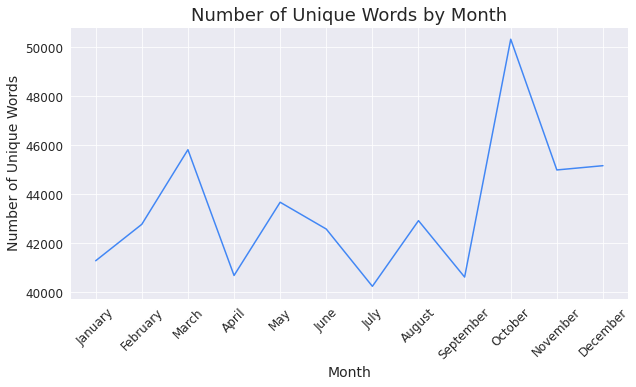

In [11]:
# FInd num;ber of unique words in each month porcessed_text and add to list and plot
num_unique_words_2021 = []
for i in range(len(df_2021)):
    text = df_2021[i]['processed_text']
    # Make a sigle list by appending all the lists in text
    text = [item for sublist in text for item in sublist]
    # Find number of unique words in the list
    num_unique_words_2021.append(len(set(text)))
    

plt.figure(figsize=(10, 5))
plt.plot(num_unique_words_2021, color='#4287f5')
plt.title('Number of Unique Words by Month', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Unique Words', fontsize=14)
plt.xticks(range(0, 12), ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()


    

In [12]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.7,
    max_features=int(30000),
    stop_words='english'
)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
def vectorize(text, maxx_features, ngram_from, ngram_to):
    
    vectorizer = TfidfVectorizer(max_df=0.7, min_df=5, max_features=maxx_features, ngram_range=(ngram_from, ngram_to))
    X = vectorizer.fit_transform(text)
    return X,vectorizer

In [14]:
import pyLDAvis
import pyLDAvis.sklearn
pyLDAvis.enable_notebook()

In [15]:
import warnings
warnings.filterwarnings('ignore')

# 2019

In [16]:
# November 2019

text_1 = df_2019[0]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,7)

nmf = NMF(n_components=5, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('November 2019')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

November 2019
Topic 0:
['virus', 'pathogen', 'strain', 'viral', 'tissue', 'vaccine', 'pneumonia', 'antibody', 'detected', 'bovine']
Topic 1:
['respiratory', 'symptom', 'therapy', 'year', 'hospital', 'child', 'health', 'dose', 'management', 'common']
Topic 2:
['assay', 'ml', 'antibody', 'elisa', 'activity', 'signal', 'protein', 'expression', 'plate', 'reaction']
Topic 3:
['mortality', 'score', 'risk', 'survival', 'rate', 'liver', 'na', 'decrease', 'factor', 'follow']
Topic 4:
['blood', 'generated', 'membrane', 'pre', 'expressing', 'subset', 'culture', 'mouse', 'expression', 'gene']


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.093818  0.132619       1        1  26.778150
1     -0.094237 -0.023697       2        1  24.640093
0      0.065571  0.148545       3        1  22.792112
3     -0.271350 -0.060044       4        1  13.353942
4      0.206198 -0.197423       5        1  12.435702, topic_info=          Term      Freq     Total Category  logprob  loglift
369  mortality  1.000000  1.000000  Default  30.0000  30.0000
632      virus  1.000000  1.000000  Default  29.0000  29.0000
58       blood  1.000000  1.000000  Default  28.0000  28.0000
520      score  0.000000  0.000000  Default  27.0000  27.0000
237  generated  0.000000  0.000000  Default  26.0000  26.0000
..         ...       ...       ...      ...      ...      ...
613       type  0.158604  0.563461   Topic5  -4.7423   0.8169
459   protocol  0.125590  0.311230   Topic5  -4.9757   1.1771
485  reduction  0.124200  0.399227   Topic5  -4.9868   0.9170
216       flow  0.114599  0.313613   Topic5  -5.0673   1.0779
615       unit  0.108216  0.455343   Topic5  -5.1246   0.6477

[261 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
11        1  1.322478     activity
37        1  0.840640     antibody
44        1  0.889971        assay
58        5  0.841978        blood
175       1  1.388102        elisa
201       1  1.098748   expression
237       5  1.461833    generated
361       1  0.943510           ml
369       4  0.709213    mortality
409       3  1.052713     pathogen
458       1  1.275428      protein
504       2  1.137237  respiratory
510       4  1.222752         risk
520       4  1.066315        score
540       1  1.808817       signal
565       3  1.383777       strain
589       2  1.584632      symptom
603       2  1.457798      therapy
629       3  0.977075        viral
632       3  1.027307        virus, R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 1, 4, 5])

In [17]:
# December

text_1 = df_2019[1]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,7)

nmf = NMF(n_components=5, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('December 2019')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

December 2019
Topic 0:
['patient', 'drug', 'lung', 'hand', 'respiratory', 'blood', 'body', 'risk', 'case', 'use']
Topic 1:
['cell', 'protein', 'expression', 'viral', 'production', 'gene', 'replication', 'response', 'rna', 'infected']
Topic 2:
['transmission', 'case', 'infected', 'epidemic', 'outbreak', 'individual', 'antibody', 'rate', 'loss', 'distance']
Topic 3:
['gene', 'assay', 'value', 'target', 'site', 'blood', 'brain', 'genetic', 'information', 'association']
Topic 4:
['specie', 'sample', 'dna', 'sequence', 'pcr', 'host', 'viral', 'isolated', 'lung', 'respiratory']


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.186217  0.001636       1        1  23.283608
3      0.089920 -0.165542       2        1  21.642036
1      0.200389  0.018981       3        1  20.881121
2     -0.117937 -0.071180       4        1  19.470590
4      0.013845  0.216105       5        1  14.722645, topic_info=             Term      Freq     Total Category  logprob  loglift
358       patient  2.000000  2.000000  Default  30.0000  30.0000
55           cell  1.000000  1.000000  Default  29.0000  29.0000
473        specie  1.000000  1.000000  Default  28.0000  28.0000
516  transmission  1.000000  1.000000  Default  27.0000  27.0000
443        sample  0.000000  0.000000  Default  26.0000  26.0000
..            ...       ...       ...      ...      ...      ...
121     detection  0.137224  0.479710   Topic5  -4.9556   0.6642
349       outcome  0.139567  0.553571   Topic5  -4.9387   0.5379
516  transmission  0.148960  1.388120   Topic5  -4.8735  -0.3162
197          gene  0.142208  1.844525   Topic5  -4.9199  -0.6469
518     treatment  0.132875  0.560841   Topic5  -4.9878   0.4758

[264 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
37        2  1.154636         assay
53        4  0.840833          case
55        3  1.194176          cell
137       5  1.475074           dna
142       1  1.282440          drug
177       3  1.233458    expression
197       2  0.542145          gene
197       3  0.542145          gene
213       1  1.476633          hand
245       4  1.056771      infected
293       1  1.175975          lung
358       1  1.102557       patient
386       3  1.635429    production
392       3  0.886396       protein
422       3  1.804237   replication
443       5  1.067734        sample
473       5  0.785343        specie
501       2  1.644975        target
516       4  0.720399  transmission
530       2  1.270531         value
537       3  0.912432         viral, R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 2, 3, 5])

# 2020

In [18]:
# Visualize the topics for each month in 2020
# January 
text_1 = df_2020[0]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('January 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

January 2020
Topic 0:
['cov', 'protein', 'cell', 'infected', 'antibody', 'sequence', 'expression', 'mutation', 'binding', 'mouse']
Topic 1:
['patient', 'acute', 'influenza', 'hospital', 'period', 'admission', 'involvement', 'mortality', 'rate', 'post']
Topic 2:
['specie', 'vaccine', 'prevalence', 'host', 'virus', 'transmission', 'presence', 'model', 'european', 'human']
Topic 3:
['ii', 'peptide', 'mouse', 'cell', 'pathway', 'induced', 'inflammatory', 'vaccine', 'activation', 'inflammation']
Topic 4:
['people', 'support', 'experience', 'service', 'body', 'life', 'treatment', 'relationship', 'pandemic', 'world']
Topic 5:
['case', 'outbreak', 'human', 'china', 'wuhan', 'coronavirus', 'january', 'cov', 'transmission', 'sars']
Topic 6:
['strain', 'gene', 'resistant', 'dna', 'protein', 'bacteria', 'coli', 'µl', 'bacterial', 'fresh']
Topic 7:
['set', 'function', 'regular', 'state', 'open', 'construct', 'accepted', 'class', 'following', 'continuous']
Topic 8:
['µl', 'virus', 'assay', 'pcr', 'r

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.033919  0.069470       1        1  15.681321
3      0.082709 -0.016592       2        1  14.255096
6      0.156765 -0.063099       3        1  14.222249
8      0.105713 -0.050945       4        1  11.329345
0      0.221422 -0.105438       5        1  10.677975
5     -0.050781  0.108467       6        1   9.812521
2      0.071608  0.071744       7        1   8.990930
4     -0.126447  0.195301       8        1   7.667112
9     -0.149303  0.073097       9        1   4.727111
7     -0.277767 -0.282005      10        1   2.636340, topic_info=         Term      Freq     Total Category  logprob  loglift
767       set  0.000000  0.000000  Default  30.0000  30.0000
594   patient  2.000000  2.000000  Default  29.0000  29.0000
643   product  1.000000  1.000000  Default  28.0000  28.0000
328  function  0.000000  0.000000  Default  27.0000  27.0000
185       cov  1.000000  1.000000  Default  26.0000  26.0000
..        ...       ...       ...      ...      ...      ...
911   version  0.055042  0.326651  Topic10  -4.7644   1.8550
762  sequence  0.062540  1.304717  Topic10  -4.6367   0.5978
556       non  0.050935  0.557619  Topic10  -4.8420   1.2426
643   product  0.058141  1.029171  Topic10  -4.7096   0.7621
100      case  0.059185  1.470281  Topic10  -4.6918   0.4232

[489 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
18        1  1.329228       acute
64        4  1.439445       assay
100       6  0.680142        case
105       2  0.605883        cell
105       5  0.605883        cell
185       5  0.653762         cov
287       8  1.770827  experience
332       3  1.053700        gene
366       1  1.380808    hospital
373       6  0.897486       human
379       2  0.776404          ii
422       1  1.114509   influenza
536       2  0.933046       mouse
579       6  1.172398    outbreak
594       1  0.796972     patient
596       4  1.298437         pcr
597       8  1.065692      people
598       2  0.801194     peptide
643       9  0.971656     product
652       5  0.557722     protein
767      10  1.018534         set
800       7  0.804519      specie
820       3  0.947654      strain
847       8  1.458313     support
915       4  0.639928       virus
955       4  0.898261          µl, R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 7, 9, 1, 6, 3, 5, 10, 8])

In [19]:
# February
text_1 = df_2020[1]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('February 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

February 2020
Topic 0:
['patient', 'surgery', 'group', 'icu', 'failure', 'mortality', 'surgical', 'hospital', 'complication', 'septic']
Topic 1:
['protein', 'structure', 'binding', 'cell', 'ml', 'sequence', 'residue', 'rna', 'tree', 'receptor']
Topic 2:
['cov', 'virus', 'human', 'sars', 'vaccine', 'coronaviruses', 'sars cov', 'ncov', 'expression', 'mers']
Topic 3:
['ct', 'patient', 'opacity', 'ground glass', 'glass', 'ground', 'chest', 'covid', 'glass opacity', 'ground glass opacity']
Topic 4:
['covid', 'patient', 'funder ha', 'granted display', 'ha granted', 'ha granted display', 'funder ha granted', 'perpetuity', 'funder', 'granted']
Topic 5:
['china', 'country', 'epidemic', 'january', 'ncov', 'travel', 'estimated', 'ci', 'screening', 'day']
Topic 6:
['brain', 'tumor', 'activity', 'mouse', 'cerebral', 'pathway', 'injury', 'mg', 'cellular', 'cancer']
Topic 7:
['community', 'trauma', 'african', 'care', 'health', 'self', 'social', 'china', 'barrier', 'africa']
Topic 8:
['child', 'infect

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.015021 -0.040678       1        1  14.177181
1     -0.211046  0.001675       2        1  13.211566
4      0.174722 -0.069315       3        1  11.518220
0     -0.080338 -0.063681       4        1  10.997907
5      0.122776  0.123204       5        1  10.969657
3      0.198365 -0.233042       6        1   9.200083
8     -0.092093 -0.092666       7        1   8.776158
6     -0.203852 -0.028860       8        1   7.876932
9      0.013721  0.177083       9        1   7.598826
7      0.092767  0.226281      10        1   5.673469, topic_info=            Term      Freq     Total Category  logprob  loglift
179        child  1.000000  1.000000  Default  30.0000  30.0000
135        brain  1.000000  1.000000  Default  29.0000  29.0000
644   individual  1.000000  1.000000  Default  28.0000  28.0000
304           ct  1.000000  1.000000  Default  27.0000  27.0000
219    community  1.000000  1.000000  Default  26.0000  26.0000
...          ...       ...       ...      ...      ...      ...
892     outbreak  0.170101  0.788473  Topic10  -4.9580   1.3357
147     capacity  0.158030  0.552628  Topic10  -5.0316   1.6175
1410       video  0.159037  0.586442  Topic10  -5.0253   1.5644
485       family  0.157557  0.728929  Topic10  -5.0346   1.3376
296        covid  0.163983  1.974559  Topic10  -4.9946   0.3810

[500 rows x 6 columns], token_table=      Topic      Freq              Term
term                                   
15        7  1.510351               act
19        8  1.185555          activity
38       10  1.061202           african
41        9  1.447356             agent
123       2  1.050557           binding
...     ...       ...               ...
1366      8  1.214116             tumor
1396      1  0.869733           vaccine
1413      1  0.528102             virus
1433      3  1.515210           wa peer
1434      3  1.515210  wa peer reviewed

[84 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 5, 1, 6, 4, 9, 7, 10, 8])

In [20]:
# March
text_1 = df_2020[2]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('March 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

March 2020
Topic 0:
['patient', 'cancer', 'care', 'hospital', 'clinic', 'covid', 'provider', 'plan', 'quarantine', 'resource']
Topic 1:
['granted display', 'funder ha', 'ha granted', 'ha granted display', 'funder', 'funder ha granted', 'display', 'granted', 'perpetuity', 'display perpetuity']
Topic 2:
['sars', 'cov', 'sars cov', 'patient', 'infection', 'covid', 'clinical', 'respiratory', 'liver', 'symptom']
Topic 3:
['individual', 'model', 'population', 'epidemic', 'infected', 'city', 'scenario', 'disease', 'region', 'peak']
Topic 4:
['cell', 'virus', 'viral', 'mouse', 'antibody', 'vaccine', 'pre', 'activity', 'ml', 'infection']
Topic 5:
['user', 'learning', 'task', 'development', 'social_medium', 'digital', 'big', 'participant', 'product', 'research']
Topic 6:
['ct', 'covid', 'patient', 'lung', 'pneumonia', 'chest', 'imaging', 'diagnosis', 'opacity', 'chest ct']
Topic 7:
['rbd', 'protein', 'ace', 'cov', 'sars', 'structure', 'sars cov', 'binding', 'residue', 'position']
Topic 8:
['curv

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.079519  0.190543       1        1  14.961591
5      0.071282 -0.187745       2        1  11.396178
1     -0.120902  0.119884       3        1  10.858235
0     -0.107559 -0.059947       4        1  10.707862
6     -0.143971  0.123001       5        1  10.576171
4      0.125405  0.089997       6        1  10.565195
9     -0.141292 -0.121987       7        1  10.287537
3     -0.087859 -0.133507       8        1   8.433937
8      0.182391 -0.168436       9        1   7.650828
7      0.302025  0.148197      10        1   4.562468, topic_info=          Term      Freq     Total Category  logprob  loglift
577        cov  5.000000  5.000000  Default  30.0000  30.0000
2344      sars  5.000000  5.000000  Default  29.0000  29.0000
1861   patient  8.000000  8.000000  Default  28.0000  28.0000
2345  sars cov  4.000000  4.000000  Default  27.0000  27.0000
2128       rbd  1.000000  1.000000  Default  26.0000  26.0000
...        ...       ...       ...      ...      ...      ...
794     domain  0.300935  0.974725  Topic10  -5.0436   1.9120
523    contact  0.303132  1.124016  Topic10  -5.0364   1.7768
2461      site  0.237099  0.594776  Topic10  -5.2820   2.1676
1658     model  0.294445  2.597234  Topic10  -5.0654   0.9102
1230     human  0.239378  1.172442  Topic10  -5.2725   1.4985

[553 rows x 6 columns], token_table=      Topic      Freq                 Term
term                                      
25       10  1.010910                  ace
36        6  0.747670             activity
75        7  1.078793               africa
76        7  1.616533              african
77        7  0.952707                  age
...     ...       ...                  ...
2837      3  0.962054  wa certified review
2854      3  0.933330              wa peer
2855      3  0.933330     wa peer reviewed
2875      7  0.969363                 week
2889      1  1.018362                woman

[190 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 6, 2, 1, 7, 5, 10, 4, 9, 8])

In [21]:
# April
text_1 = df_2020[3]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Apr 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Apr 2020
Topic 0:
['cov', 'sars', 'sars cov', 'protein', 'virus', 'mers', 'mers cov', 'pangolin', 'cov infection', 'sars cov infection']
Topic 1:
['perpetuity', 'granted display', 'ha granted display', 'funder ha granted', 'display perpetuity', 'funder ha', 'granted display perpetuity', 'funder', 'ha granted', 'granted']
Topic 2:
['country', 'people', 'outbreak', 'population', 'number', 'italy', 'health', 'pandemic', 'epidemic', 'china']
Topic 3:
['ct', 'chest', 'lung', 'pneumonia', 'image', 'chest ct', 'severe', 'day', 'clinical', 'covid pneumonia']
Topic 4:
['cell', 'cd', 'protein', 'mouse', 'cd cell', 'virus', 'antibody', 'vaccine', 'immune', 'memory']
Topic 5:
['ace', 'angiotensin', 'receptor', 'hypertension', 'arb', 'angiotensin ii', 'ii', 'ace receptor', 'therapy', 'lung']
Topic 6:
['sample', 'pcr', 'swab', 'test', 'rt', 'specimen', 'assay', 'respiratory', 'tract', 'respiratory tract']
Topic 7:
['graph', 'edge', 'set', 'model', 'algorithm', 'let', 'problem', 'theorem', 'proof', '

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9      0.016755  0.011306       1        1  18.819669
2      0.072306 -0.022543       2        1  18.144023
3     -0.061880 -0.073662       3        1  10.880606
1      0.250094 -0.226188       4        1  10.333382
4     -0.043045  0.155244       5        1   7.920763
0     -0.147213 -0.051024       6        1   7.809611
6      0.042039  0.005623       7        1   7.553208
8     -0.127681 -0.027653       8        1   6.966103
7      0.216699  0.227178       9        1   5.892896
5     -0.218075  0.001718      10        1   5.679738, topic_info=          Term       Freq      Total Category  logprob  loglift
802        cov  11.000000  11.000000  Default  30.0000  30.0000
3252      sars  10.000000  10.000000  Default  29.0000  29.0000
3253  sars cov   9.000000   9.000000  Default  28.0000  28.0000
1566     graph   6.000000   6.000000  Default  27.0000  27.0000
30         ace   5.000000   5.000000  Default  26.0000  26.0000
...        ...        ...        ...      ...      ...      ...
3355    severe   0.695702   3.993460  Topic10  -5.4189   1.1208
882   cytokine   0.621799   2.022752  Topic10  -5.5312   1.6887
1159    effect   0.646922   2.914879  Topic10  -5.4916   1.3629
470       cell   0.658235   6.987935  Topic10  -5.4742   0.5059
1697      host   0.602549   1.843953  Topic10  -5.5626   1.7498

[570 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
30        6  0.172489             ace
30       10  0.862444             ace
31       10  0.823793    ace receptor
71        8  0.910651  administration
73        3  0.518718       admission
...     ...       ...             ...
4028      2  1.123946            west
4045      1  0.435542            work
4073      2  0.451345            year
4073      3  0.451345            year
4090      7  0.592456              µl

[481 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 3, 4, 2, 5, 1, 7, 9, 8, 6])

In [22]:
# May
text_1 = df_2020[4]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('May 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

May 2020
Topic 0:
['cov', 'sars cov', 'sars', 'rna', 'pcr', 'sequence', 'virus', 'genome', 'protein', 'assay']
Topic 1:
['available funder ha', 'available funder', 'international available funder', 'international available', 'cc by', 'cc', 'nd international', 'nd international available', 'funder ha', 'perpetuity']
Topic 2:
['hcws', 'procedure', 'ppe', 'surgical', 'surgery', 'aerosol', 'mask', 'testing', 'hospital', 'endoscopy']
Topic 3:
['severe', 'ct', 'treatment', 'day', 'infection', 'pneumonia', 'symptom', 'lung', 'admission', 'icu']
Topic 4:
['cell', 'protein', 'cd', 'il', 'expression', 'ifn', 'infection', 'immune', 'virus', 'cytokine']
Topic 5:
['model', 'image', 'network', 'parameter', 'node', 'user', 'value', 'function', 'method', 'based']
Topic 6:
['review funder', 'review funder ha', 'certified review funder', 'wa certified review', 'certified review', 'wa certified', 'perpetuity', 'funder ha', 'funder ha granted', 'granted display perpetuity']
Topic 7:
['ace', 'angiotensin',

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9     -0.027327  0.188066       1        1  23.643165
3      0.022290 -0.034729       2        1  16.688532
5     -0.018085  0.153844       3        1  12.444773
2     -0.021851  0.192326       4        1  10.599381
4      0.154268 -0.098618       5        1   8.441501
0      0.084986  0.021121       6        1   7.508281
1     -0.297582 -0.064470       7        1   7.455007
8      0.176356 -0.012188       8        1   5.500400
6     -0.262538 -0.165301       9        1   4.316741
7      0.189483 -0.180052      10        1   3.402220, topic_info=                Term       Freq      Total Category  logprob  loglift
33               ace   9.000000   9.000000  Default  30.0000  30.0000
476             cell  11.000000  11.000000  Default  29.0000  29.0000
818              cov  15.000000  15.000000  Default  28.0000  28.0000
3257        sars cov  14.000000  14.000000  Default  27.0000  27.0000
655         compound   6.000000   6.000000  Default  26.0000  26.0000
...              ...        ...        ...      ...      ...      ...
3256            sars   1.158298  15.550179  Topic10  -4.8766   0.7836
3257        sars cov   1.099901  14.877003  Topic10  -4.9284   0.7761
818              cov   1.098631  15.516721  Topic10  -4.9295   0.7329
1923          injury   0.736364   3.300842  Topic10  -5.3296   1.8805
433   cardiovascular   0.656490   2.149848  Topic10  -5.4444   2.1945

[618 rows x 6 columns], token_table=      Topic      Freq                 Term
term                                      
0         5  0.727360                   aa
5         2  0.794150             abnormal
18        1  0.876191               access
33       10  0.971954                  ace
35       10  0.642414       ace expression
...     ...       ...                  ...
3982      7  0.297211  wa certified review
3982      9  0.594423  wa certified review
4024      4  0.853755              wearing
4032      1  1.510328           well being
4052      3  0.667156                 word

[675 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 4, 6, 3, 5, 1, 2, 9, 7, 8])

In [23]:
# June
text_1 = df_2020[5]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('June 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

June 2020
Topic 0:
['protein', 'vaccine', 'antibody', 'cov', 'sars', 'sars cov', 'rbd', 'spike', 'cell', 'binding']
Topic 1:
['pandemic', 'health', 'people', 'social', 'country', 'respondent', 'disease', 'woman', 'individual', 'population']
Topic 2:
['funder ha', 'perpetuity', 'funder', 'ha granted display', 'granted display', 'funder ha granted', 'display perpetuity', 'granted display perpetuity', 'ha granted', 'posted june']
Topic 3:
['disease', 'cardiac', 'severe', 'risk', 'treatment', 'covid patient', 'clinical', 'mortality', 'day', 'admission']
Topic 4:
['il', 'cell', 'inflammatory', 'activation', 'lung', 'cd', 'ace', 'cytokine', 'pathway', 'mouse']
Topic 5:
['model', 'data', 'algorithm', 'proof', 'value', 'method', 'number', 'network', 'problem', 'result']
Topic 6:
['mask', 'aerosol', 'respirator', 'surgical', 'droplet', 'ppe', 'face_mask', 'procedure', 'room', 'filter']
Topic 7:
['care', 'visit', 'service', 'telehealth', 'provider', 'health', 'hf', 'telemedicine', 'pandemic', 'a

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.092508 -0.027119       1        1  17.406368
1     -0.118120  0.011891       2        1  16.715271
9      0.124630 -0.028523       3        1  12.777051
5     -0.050788 -0.022288       4        1  12.541491
7     -0.193382 -0.056448       5        1   9.755276
4      0.217246 -0.107958       6        1   9.133167
6     -0.081605 -0.061681       7        1   7.558618
0      0.165918 -0.099378       8        1   6.392461
2      0.069496  0.402068       9        1   3.998602
8     -0.225903 -0.010565      10        1   3.721695, topic_info=            Term       Freq      Total Category  logprob  loglift
812          cov  17.000000  17.000000  Default  30.0000  30.0000
3579     student   6.000000   6.000000  Default  29.0000  29.0000
3282    sars cov  16.000000  16.000000  Default  28.0000  28.0000
3281        sars  16.000000  16.000000  Default  27.0000  27.0000
1774          il   7.000000   7.000000  Default  26.0000  26.0000
...          ...        ...        ...      ...      ...      ...
2875     problem   0.899433   4.036978  Topic10  -5.1965   1.7895
1055     digital   0.769763   2.924039  Topic10  -5.3521   1.9564
1352  experience   0.689760   3.202986  Topic10  -5.4619   1.7555
1602       group   0.736250   6.098917  Topic10  -5.3966   1.1767
1396      factor   0.674432   4.314920  Topic10  -5.4843   1.4350

[609 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
14        2  0.634846  academic
14       10  0.634846  academic
17        2  0.307840    access
17        5  0.615680    access
28        1  0.203983       ace
...     ...       ...       ...
4029      7  0.982146   wearing
4051      2  0.949882     woman
4052      2  1.962080     women
4062      2  0.811045     world
4094      3  0.919718        μl

[691 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 10, 6, 8, 5, 7, 1, 3, 9])

In [24]:
# July
text_1 = df_2020[6]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('July 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

July 2020
Topic 0:
['surgical', 'hospital', 'ppe', 'surgery', 'room', 'procedure', 'aerosol', 'anesthesia', 'risk', 'staff']
Topic 1:
['cov', 'sars', 'sars cov', 'virus', 'assay', 'infection', 'pcr', 'positive', 'sample', 'symptom']
Topic 2:
['granted display', 'granted display perpetuity', 'funder ha granted', 'perpetuity', 'funder ha', 'display perpetuity', 'ha granted', 'ha granted display', 'posted july', 'version posted']
Topic 3:
['pandemic', 'health', 'country', 'government', 'social', 'people', 'practice', 'public', 'care', 'need']
Topic 4:
['icu', 'clinical', 'day', 'severe', 'injury', 'il', 'ards', 'cytokine', 'lung', 'cardiac']
Topic 5:
['anxiety', 'depression', 'mental_health', 'psychological', 'burnout', 'anxiety depression', 'symptom', 'stress', 'depression anxiety', 'participant']
Topic 6:
['model', 'parameter', 'number', 'value', 'pm', 'analysis', 'control', 'variable', 'method', 'period']
Topic 7:
['protein', 'binding', 'nsp', 'energy', 'compound', 'structure', 'virus'

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.082928  0.092920       1        1  17.892068
4      0.019355  0.050095       2        1  16.099945
6      0.004686 -0.014832       3        1  13.914150
1      0.066581 -0.019533       4        1  12.036644
0     -0.104108  0.120274       5        1   9.260290
8      0.258270 -0.040184       6        1   8.576787
7      0.270166 -0.030207       7        1   6.922825
5     -0.129728  0.044199       8        1   6.731432
9     -0.120488  0.131164       9        1   5.052100
2     -0.181806 -0.333896      10        1   3.513758, topic_info=               Term       Freq      Total Category  logprob  loglift
452          cancer   9.000000   9.000000  Default  30.0000  30.0000
510            cell  12.000000  12.000000  Default  29.0000  29.0000
825             cov  15.000000  15.000000  Default  28.0000  28.0000
3270       sars cov  15.000000  15.000000  Default  27.0000  27.0000
3269           sars  15.000000  15.000000  Default  26.0000  26.0000
...             ...        ...        ...      ...      ...      ...
3213  review funder   1.152768   1.318902  Topic10  -4.7847   3.2139
2009           july   1.500499   1.861233  Topic10  -4.5211   3.1330
1087        display   1.392704   1.717875  Topic10  -4.5956   3.1386
1118            doi   1.248789   1.556726  Topic10  -4.7047   3.1281
1119        doi org   1.248789   1.556726  Topic10  -4.7047   3.1281

[600 rows x 6 columns], token_table=      Topic      Freq                 Term
term                                      
9         3  0.902720             absolute
20        1  0.882205               access
35        6  1.002983                  ace
36        6  0.832943       ace expression
37        6  1.073937        ace inhibitor
...     ...       ...                  ...
3989     10  0.733201  wa certified review
3995      4  0.961082          wa detected
4025      8  0.755831                 wave
4058      1  0.683445                 work
4058      3  0.341723                 work

[639 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 5, 7, 2, 1, 9, 8, 6, 10, 3])

In [25]:
# August
text_1 = df_2020[7]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Aug 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Aug 2020
Topic 0:
['patient', 'hospital', 'disease', 'surgery', 'treatment', 'cancer', 'covid patient', 'clinical', 'risk', 'liver']
Topic 1:
['child', 'participant', 'social', 'pandemic', 'mental_health', 'family', 'people', 'nurse', 'suicide', 'health']
Topic 2:
['cell', 'protein', 'ace', 'cov', 'sars', 'virus', 'sars cov', 'viral', 'drug', 'human']
Topic 3:
['funder ha', 'funder ha granted', 'granted display', 'ha granted display', 'funder', 'ha granted', 'version posted', 'version posted august', 'posted august', 'holder version posted']
Topic 4:
['cov', 'sars cov', 'sars', 'swab', 'pcr', 'rt', 'specimen', 'transmission', 'rt pcr', 'sample']
Topic 5:
['student', 'teacher', 'learning', 'teaching', 'course', 'education', 'english', 'educational', 'game', 'faculty']
Topic 6:
['image', 'user', 'object', 'model', 'detection', 'network', 'method', 'algorithm', 'matrix', 'area']
Topic 7:
['day', 'patient', 'mg', 'ct', 'pneumonia', 'chest', 'lung', 'mg dl', 'dl', 'covid pneumonia']
Topic 8

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.141087 -0.006566       1        1  16.306472
6     -0.149702 -0.002766       2        1  12.756113
2      0.072968 -0.122264       3        1  12.677049
0      0.061933 -0.045816       4        1  12.626665
1     -0.140753 -0.001708       5        1  12.545238
4      0.102342 -0.052022       6        1  11.402617
7      0.217248 -0.082195       7        1   9.206520
5     -0.270650 -0.035725       8        1   5.700582
3      0.073202  0.367442       9        1   3.830323
9      0.174498 -0.018381      10        1   2.948422, topic_info=              Term       Freq      Total Category  logprob  loglift
2631       patient  25.000000  25.000000  Default  30.0000  30.0000
3553        stroke   7.000000   7.000000  Default  29.0000  29.0000
3560       student   7.000000   7.000000  Default  28.0000  28.0000
818            cov  16.000000  16.000000  Default  27.0000  27.0000
3255      sars cov  15.000000  15.000000  Default  26.0000  26.0000
...            ...        ...        ...      ...      ...      ...
1721  hospitalized   0.487901   2.153393  Topic10  -5.4595   2.0392
2530         onset   0.466536   2.207411  Topic10  -5.5042   1.9697
1718      hospital   0.561340   7.077678  Topic10  -5.3193   0.9895
235        article   0.455832   2.920933  Topic10  -5.5275   1.6664
2672        period   0.456039   3.359299  Topic10  -5.5270   1.5270

[598 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
0         6  1.140352            ab
10        5  0.704019         abuse
30        2  0.778715      accuracy
33        3  0.814478           ace
56        4  0.334566         acute
...     ...       ...           ...
4053      5  0.269964          work
4053      8  0.269964          work
4067      7  0.656762     worsening
4085      5  0.685901         young
4087      5  1.487082  young people

[617 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 7, 3, 1, 2, 5, 8, 6, 4, 10])

In [26]:
# September
text_1 = df_2020[8]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Sept 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Sept 2020
Topic 0:
['cov', 'sars cov', 'sars', 'infection', 'virus', 'sample', 'antibody', 'rbd', 'viral', 'protein']
Topic 1:
['health', 'country', 'pandemic', 'people', 'risk', 'economic', 'care', 'mental_health', 'service', 'government']
Topic 2:
['funder', 'ha granted display', 'granted display', 'ha granted', 'funder ha', 'funder ha granted', 'perpetuity', 'granted', 'granted display perpetuity', 'display perpetuity']
Topic 3:
['risk', 'day', 'severe', 'il', 'infection', 'clinical', 'blood', 'group', 'treatment', 'inflammatory']
Topic 4:
['cell', 'protein', 'rna', 'expression', 'compound', 'virus', 'gene', 'cd', 'mouse', 'brain']
Topic 5:
['student', 'online', 'school', 'teaching', 'digital', 'learning', 'video', 'medical', 'technology', 'virtual']
Topic 6:
['model', 'fractional', 'dataset', 'image', 'class', 'derivative', 'rate', 'individual', 'prediction', 'infected']
Topic 7:
['cancer', 'cancer patient', 'treatment', 'cervical', 'stage', 'delay', 'breast', 'care', 'net', 'tumor

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.015882 -0.144193       1        1  19.713552
3      0.041545  0.039356       2        1  18.761044
4      0.210372  0.104880       3        1  12.825522
5      0.017852 -0.201230       4        1  10.466380
6      0.020889  0.023084       5        1  10.268701
0      0.120384  0.222389       6        1   8.926662
9      0.028065 -0.053575       7        1   6.485595
2     -0.330551  0.168645       8        1   4.937232
7     -0.048721 -0.124607       9        1   4.403529
8     -0.043953 -0.034750      10        1   3.211781, topic_info=          Term       Freq      Total Category  logprob  loglift
444     cancer   9.000000   9.000000  Default  30.0000  30.0000
845        cov  11.000000  11.000000  Default  29.0000  29.0000
3557    stroke   6.000000   6.000000  Default  28.0000  28.0000
3272  sars cov  11.000000  11.000000  Default  27.0000  27.0000
3271      sars  10.000000  10.000000  Default  26.0000  26.0000
...        ...        ...        ...      ...      ...      ...
409      brain   0.424583   2.874036  Topic10  -5.6189   1.5260
3421      site   0.412779   2.553504  Topic10  -5.6471   1.6160
2607   outcome   0.439815   3.725038  Topic10  -5.5836   1.3019
464       care   0.467605   6.081869  Topic10  -5.5224   0.8729
2631  pandemic   0.461435   6.494971  Topic10  -5.5356   0.7939

[599 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
1         6  0.922178            ab
2         5  1.308530           abc
7         2  0.882413   abnormality
28        5  0.697180      accuracy
31        2  0.340887           ace
...     ...       ...           ...
4012      1  1.540353           war
4022      7  0.770021       wearing
4023      7  1.441204  wearing mask
4057      1  0.931148        worker
4062      4  1.086566      workshop

[584 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 5, 6, 7, 1, 10, 3, 8, 9])

In [27]:
# October
text_1 = df_2020[9]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Oct 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Oct 2020
Topic 0:
['cov', 'sars cov', 'sars', 'infection', 'sample', 'antibody', 'virus', 'pcr', 'viral', 'cov infection']
Topic 1:
['health', 'mental_health', 'psychological', 'participant', 'care', 'social', 'pandemic', 'respondent', 'anxiety', 'people']
Topic 2:
['granted display', 'ha granted display', 'funder', 'funder ha', 'ha granted', 'funder ha granted', 'version posted', 'version posted october', 'holder version', 'posted october']
Topic 3:
['cell', 'protein', 'cd', 'gene', 'virus', 'expression', 'il', 'cytokine', 'infection', 'viral']
Topic 4:
['treatment', 'mortality', 'day', 'hospital', 'severe', 'admission', 'covid patient', 'icu', 'clinical', 'trial']
Topic 5:
['model', 'image', 'ai', 'method', 'parameter', 'learning', 'value', 'proposed', 'network', 'information']
Topic 6:
['student', 'program', 'school', 'education', 'medical', 'learning', 'interview', 'virtual', 'medical student', 'applicant']
Topic 7:
['surgery', 'surgical', 'mask', 'hospital', 'staff', 'procedure', 

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.056987 -0.042484       1        1  17.280128
1     -0.157190  0.037175       2        1  17.208388
5     -0.071483  0.023261       3        1  16.344999
7     -0.149569  0.030625       4        1  10.795940
0      0.137257 -0.043443       5        1   8.998830
3      0.235204  0.062108       6        1   7.534626
6     -0.234688  0.110420       7        1   7.176289
9      0.236618  0.091483       8        1   5.794560
2     -0.033193 -0.359448       9        1   4.737233
8     -0.019941  0.090305      10        1   4.129008, topic_info=            Term       Freq      Total Category  logprob  loglift
3876     vaccine   8.000000   8.000000  Default  30.0000  30.0000
806          cov  12.000000  12.000000  Default  29.0000  29.0000
3253    sars cov  11.000000  11.000000  Default  28.0000  28.0000
3252        sars  12.000000  12.000000  Default  27.0000  27.0000
485         cell  10.000000  10.000000  Default  26.0000  26.0000
...          ...        ...        ...      ...      ...      ...
2901  protection   0.554391   1.692239  Topic10  -5.6753   2.0712
2746  population   0.718819   4.929677  Topic10  -5.4155   1.2617
626    community   0.639205   3.234874  Topic10  -5.5329   1.5656
2734      policy   0.618653   3.112155  Topic10  -5.5656   1.5716
1593       group   0.604341   5.582304  Topic10  -5.5890   0.9639

[575 rows x 6 columns], token_table=      Topic      Freq           Term
term                                
29        7  1.191786  accreditation
31        3  1.181956       accuracy
34        5  0.392031            ace
34        6  0.196015            ace
34        8  0.392031            ace
...     ...       ...            ...
4029      2  0.709623     well being
4030      2  1.018515      wellbeing
4049      1  0.375358          woman
4049      2  0.750717          woman
4095      8  1.846320             μm

[610 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 2, 6, 8, 1, 4, 7, 10, 3, 9])

In [28]:
# November
text_1 = df_2020[10]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Nov 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Nov 2020
Topic 0:
['health', 'service', 'care', 'worker', 'work', 'people', 'community', 'nurse', 'social', 'dental']
Topic 1:
['cell', 'cd', 'ace', 'tissue', 'endothelial', 'kidney', 'gene', 'expression', 'anti', 'endothelial cell']
Topic 2:
['granted display', 'ha granted display', 'funder ha', 'funder ha granted', 'ha granted', 'funder', 'holder version', 'posted november', 'holder version posted', 'version posted']
Topic 3:
['protein', 'sequence', 'virus', 'genome', 'spike', 'vaccine', 'epitope', 'gene', 'binding', 'site']
Topic 4:
['ct', 'chest', 'chest ct', 'lung', 'scan', 'lesion', 'pneumonia', 'ct scan', 'pulmonary', 'pcr']
Topic 5:
['sars', 'cov', 'sars cov', 'infection', 'assay', 'cov infection', 'sars cov infection', 'virus', 'transmission', 'viral']
Topic 6:
['model', 'lockdown', 'country', 'value', 'learning', 'effect', 'distance', 'prediction', 'pollution', 'transmission']
Topic 7:
['participant', 'anxiety', 'stress', 'score', 'depression', 'mental_health', 'survey', 'sym

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.087572 -0.011941       1        1  17.179022
9     -0.102465 -0.005002       2        1  14.587268
7      0.104588  0.039247       3        1  13.327054
0      0.207031 -0.008007       4        1  11.076674
5     -0.163207  0.048077       5        1  10.519241
1     -0.153593 -0.196934       6        1   8.220016
3     -0.075458 -0.185898       7        1   8.018311
4     -0.097073  0.057212       8        1   7.046413
2     -0.076194  0.300150       9        1   5.527067
8      0.268799 -0.036903      10        1   4.498934, topic_info=             Term       Freq      Total Category  logprob  loglift
217     applicant   8.000000   8.000000  Default  30.0000  30.0000
3252         sars  13.000000  13.000000  Default  29.0000  29.0000
797           cov  12.000000  12.000000  Default  28.0000  28.0000
3253     sars cov  12.000000  12.000000  Default  27.0000  27.0000
469          cell   9.000000   9.000000  Default  26.0000  26.0000
...           ...        ...        ...      ...      ...      ...
2045     learning   0.931889   3.562570  Topic10  -5.1854   1.7603
3344      service   0.886482   4.083973  Topic10  -5.2353   1.5738
1898  institution   0.641320   1.825214  Topic10  -5.5590   2.0554
2674       person   0.763311   3.147494  Topic10  -5.3849   1.6846
218   application   0.607559   1.680859  Topic10  -5.6131   2.0837

[590 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
13        5  0.969412           ac
19        4  0.423887       access
31        1  1.831736  accumulated
33        1  0.583022     accuracy
36        5  0.260097          ace
...     ...       ...          ...
4053      1  1.613959         wind
4059      3  0.290733         work
4059      4  0.581466         work
4061      4  0.745914       worker
4062      4  0.966440    workforce

[614 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 10, 8, 1, 6, 2, 4, 5, 3, 9])

In [29]:
# December
text_1 = df_2020[11]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Dec 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Dec 2020
Topic 0:
['health', 'country', 'model', 'community', 'economic', 'policy', 'social', 'people', 'service', 'crisis']
Topic 1:
['cell', 'protein', 'ace', 'viral', 'sars', 'cov', 'sars cov', 'receptor', 'nsp', 'ifn']
Topic 2:
['granted display', 'ha granted display', 'funder ha granted', 'funder ha', 'funder', 'ha granted', 'holder version', 'holder version posted', 'version posted', 'posted december']
Topic 3:
['ct', 'lung', 'chest', 'symptom', 'day', 'pulmonary', 'lobe', 'severe', 'diagnosis', 'opacity']
Topic 4:
['cov', 'sars cov', 'sars', 'antibody', 'igg', 'assay', 'sample', 'detection', 'titer', 'igm']
Topic 5:
['surgery', 'ppe', 'surgical', 'care', 'staff', 'procedure', 'practice', 'team', 'mask', 'center']
Topic 6:
['mental_health', 'anxiety', 'depression', 'psychological', 'participant', 'score', 'mental', 'stress', 'questionnaire', 'sleep']
Topic 7:
['student', 'learning', 'nutrition', 'competency', 'education', 'school', 'seminar', 'burnout', 'station', 'advocacy']
Top

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.112752 -0.058325       1        1  15.117690
8     -0.058371  0.047773       2        1  12.793363
1     -0.208233 -0.020292       3        1  12.256698
5      0.087860 -0.101192       4        1  11.516758
3     -0.139798 -0.007286       5        1  10.346853
4     -0.162933 -0.021366       6        1   9.885775
9     -0.081439 -0.061347       7        1   9.349438
6      0.162517 -0.024804       8        1   8.563632
7      0.204262 -0.099413       9        1   5.398733
2      0.083383  0.346252      10        1   4.771062, topic_info=           Term       Freq      Total Category  logprob  loglift
3563    student   8.000000   8.000000  Default  30.0000  30.0000
813         cov  14.000000  14.000000  Default  29.0000  29.0000
489        cell  11.000000  11.000000  Default  28.0000  28.0000
3256   sars cov  13.000000  13.000000  Default  27.0000  27.0000
3255       sars  13.000000  13.000000  Default  26.0000  26.0000
...         ...        ...        ...      ...      ...      ...
1114    doi org   1.473657   1.599338  Topic10  -4.8185   2.9608
1113        doi   1.464372   1.595467  Topic10  -4.8248   2.9569
1083    display   1.732407   2.006801  Topic10  -4.6567   2.8956
509   certified   1.407591   1.546425  Topic10  -4.8644   2.9485
933    december   1.378289   2.090359  Topic10  -4.8854   2.6261

[576 rows x 6 columns], token_table=      Topic      Freq                 Term
term                                      
14        9  0.747533             academic
34        3  0.797957                  ace
34        6  0.159591                  ace
49        3  1.017498           activation
62        3  1.196028                 adam
...     ...       ...                  ...
3973     10  1.188279  wa certified review
4034      1  1.017501              welfare
4054      1  0.340524                woman
4054      8  0.340524                woman
4064      1  0.558290                world

[619 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 9, 2, 6, 4, 5, 10, 7, 8, 3])

# 2021

In [30]:
# Visualize the topics for each month in 2021
# January 
text_1 = df_2021[0]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('January 2020')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

January 2020
Topic 0:
['model', 'pm', 'parameter', 'value', 'lockdown', 'transmission', 'air', 'infected', 'population', 'rate']
Topic 1:
['cov', 'sars', 'sars cov', 'ace', 'antibody', 'infection', 'cov infection', 'sars cov infection', 'virus', 'pcr']
Topic 2:
['patient', 'mortality', 'admission', 'day', 'hospital', 'treatment', 'covid patient', 'icu', 'tracheostomy', 'clinical']
Topic 3:
['granted display', 'ha granted display', 'funder ha', 'funder ha granted', 'funder', 'ha granted', 'holder version', 'posted january', 'holder version posted', 'version posted']
Topic 4:
['cell', 'cd', 'inflammatory', 'mouse', 'lung', 'macrophage', 'expression', 'tissue', 'inflammation', 'receptor']
Topic 5:
['vaccine', 'vaccination', 'covid vaccine', 'influenza', 'hesitancy', 'trial', 'africa', 'respondent', 'bnt', 'influenza vaccine']
Topic 6:
['student', 'learning', 'lecture', 'teaching', 'online', 'course', 'video', 'curriculum', 'feedback', 'education']
Topic 7:
['image', 'ct', 'model', 'networ

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9      0.156782  0.080996       1        1  21.363030
2     -0.000123 -0.014444       2        1  18.579136
1     -0.171448 -0.048386       3        1  11.528890
0      0.032016  0.023989       4        1  10.894614
4     -0.232744  0.024276       5        1   8.990136
8     -0.179166  0.081166       6        1   8.568042
7      0.021252  0.094212       7        1   7.012241
6      0.221006  0.141256       8        1   5.014919
5      0.059758 -0.021409       9        1   4.115988
3      0.092666 -0.361655      10        1   3.933003, topic_info=               Term       Freq      Total Category  logprob  loglift
826             cov  18.000000  18.000000  Default  30.0000  30.0000
3888        vaccine  10.000000  10.000000  Default  29.0000  29.0000
3264       sars cov  17.000000  17.000000  Default  28.0000  28.0000
2645        patient  29.000000  29.000000  Default  27.0000  27.0000
3263           sars  18.000000  18.000000  Default  26.0000  26.0000
...             ...        ...        ...      ...      ...      ...
3972   wa certified   1.599530   1.719714  Topic10  -4.6350   3.1633
1090        display   1.863639   2.109802  Topic10  -4.4822   3.1117
515       certified   1.479158   1.679377  Topic10  -4.7133   3.1088
2018        january   1.391987   2.997392  Topic10  -4.7740   2.4688
1733  https doi org   1.285986   1.371330  Topic10  -4.8532   3.1715

[581 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
16        8  0.805065      academic
21        9  1.090225    acceptance
34        7  0.559458      accuracy
37        3  0.616465           ace
37        5  0.246586           ace
...     ...       ...           ...
4047      4  1.194178        winter
4050      1  0.610875          work
4082      1  1.079708         young
4083      1  0.680782  young people
4085      1  1.168616         youth

[628 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 3, 2, 1, 5, 9, 8, 7, 6, 4])

In [31]:
# February
text_1 = df_2021[1]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('January 2021')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

January 2021
Topic 0:
['patient', 'cardiac', 'hospital', 'icu', 'treatment', 'covid patient', 'day', 'injury', 'infection', 'clinical']
Topic 1:
['display perpetuity', 'granted display perpetuity', 'international available funder', 'available funder', 'available funder ha', 'by nc', 'cc by nc', 'cc by', 'international available', 'nd international']
Topic 2:
['certified review', 'wa certified', 'wa certified review', 'funder ha granted', 'ha granted display', 'ha granted', 'funder ha', 'granted display', 'funder', 'certified']
Topic 3:
['cell', 'ace', 'il', 'protein', 'expression', 'cytokine', 'net', 'cd', 'immune', 'mouse']
Topic 4:
['vaccine', 'vaccination', 'covid vaccine', 'dose', 'hesitancy', 'covid vaccination', 'population', 'vaccine hesitancy', 'breastfeeding', 'influenza']
Topic 5:
['cov', 'sars cov', 'sars', 'mutation', 'virus', 'protein', 'orf', 'antibody', 'genome', 'viral']
Topic 6:
['student', 'learning', 'school', 'teacher', 'education', 'anatomy', 'online', 'child', 'co

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.065046  0.004534       1        1  17.216104
8      0.122377  0.159476       2        1  17.113761
0      0.066628 -0.084304       3        1  13.728664
9      0.043124  0.101830       4        1  12.849024
3      0.111127 -0.216975       5        1  11.134173
5      0.041954 -0.230626       6        1  10.397050
6      0.117947  0.193498       7        1   6.334953
4      0.081796  0.041299       8        1   4.899643
1     -0.347813  0.033958       9        1   3.271118
2     -0.302185 -0.002688      10        1   3.055508, topic_info=                       Term       Freq      Total Category  logprob  loglift
3889                vaccine  13.000000  13.000000  Default  30.0000  30.0000
3552                student  11.000000  11.000000  Default  29.0000  29.0000
2624                patient  23.000000  23.000000  Default  28.0000  28.0000
485                    cell  12.000000  12.000000  Default  27.0000  27.0000
3888            vaccination   8.000000   8.000000  Default  26.0000  26.0000
...                     ...        ...        ...      ...      ...      ...
2762                 posted   1.124660   2.482844  Topic10  -4.7769   2.6963
1690                 holder   1.085009   2.437678  Topic10  -4.8127   2.6788
2665             perpetuity   1.042807   2.878142  Topic10  -4.8524   2.4730
2764  posted february https   0.957421   2.007169  Topic10  -4.9378   2.7480
3179                 review   0.962707   3.896930  Topic10  -4.9323   2.0900

[594 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
7         2  0.668675    abortion
39        5  0.567073         ace
39        6  0.425305         ace
55        5  1.092287   activated
56        5  0.977262  activation
...     ...       ...         ...
4041      6  0.200851       woman
4045      1  0.216040        work
4045      2  0.432080        work
4049      2  0.898308   workforce
4086      1  0.925223        zero

[666 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 9, 1, 10, 4, 6, 7, 5, 2, 3])

In [32]:
# March
text_1 = df_2021[2]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Feb 2021')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Feb 2021
Topic 0:
['patient', 'treatment', 'hospital', 'covid patient', 'clinical', 'icu', 'ct', 'severe', 'admission', 'care']
Topic 1:
['cell', 'msc', 'cytokine', 'il', 'expression', 'inflammatory', 'cd', 'activation', 'immune', 'lung']
Topic 2:
['available funder', 'available funder ha', 'international available funder', 'international available', 'cc by', 'nd international available', 'nd international', 'by nc nd', 'nc nd international', 'nc nd']
Topic 3:
['wa certified review', 'certified review', 'wa certified', 'ha granted', 'funder', 'granted display', 'funder ha granted', 'funder ha', 'ha granted display', 'certified']
Topic 4:
['cov', 'sars cov', 'sars', 'infection', 'cov infection', 'sars cov infection', 'pcr', 'child', 'symptom', 'positive']
Topic 5:
['vaccine', 'vaccination', 'covid vaccine', 'country', 'vaccinated', 'dos', 'dose', 'bangladesh', 'pneumococcal', 'health']
Topic 6:
['participant', 'pandemic', 'health', 'student', 'social', 'service', 'community', 'anxiety',

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.065731 -0.212628       1        1  25.019573
7     -0.068664 -0.071528       2        1  16.440876
0     -0.068125 -0.107986       3        1  15.225879
4     -0.065920  0.048595       4        1  11.147023
1     -0.161713  0.136683       5        1   9.462689
9     -0.118920  0.097199       6        1   8.287368
5     -0.068164 -0.182020       7        1   5.392774
8     -0.045489  0.258521       8        1   3.843848
3      0.307667  0.038004       9        1   2.737002
2      0.355059 -0.004839      10        1   2.442970, topic_info=                    Term       Freq      Total Category  logprob  loglift
3890             vaccine  15.000000  15.000000  Default  30.0000  30.0000
2618             patient  28.000000  28.000000  Default  29.0000  29.0000
818                  cov  21.000000  21.000000  Default  28.0000  28.0000
3249            sars cov  20.000000  20.000000  Default  27.0000  27.0000
3248                sars  20.000000  20.000000  Default  26.0000  26.0000
...                  ...        ...        ...      ...      ...      ...
1573     granted display   1.641606   4.205472  Topic10  -4.3123   2.7712
1598          ha granted   1.641606   4.205472  Topic10  -4.3123   2.7712
1599  ha granted display   1.641606   4.205472  Topic10  -4.3123   2.7712
1572             granted   1.420759   3.829488  Topic10  -4.4567   2.7204
1064             display   1.211212   3.384684  Topic10  -4.6163   2.6843

[578 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
18        7  1.222517      accept
20        7  0.598196  acceptance
38        4  0.325634         ace
38        5  0.325634         ace
38        6  0.162817         ace
...     ...       ...         ...
4069      8  0.586714          wt
4076      6  1.387551       yeast
4087      2  0.901005        zero
4090      5  0.584637          µg
4090      8  0.584637          µg

[698 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 8, 1, 5, 2, 10, 6, 9, 4, 3])

In [33]:
# April
text_1 = df_2021[3]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Apr 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Apr 21
Topic 0:
['gene', 'protein', 'model', 'genome', 'sequence', 'virus', 'mutation', 'target', 'learning', 'variant']
Topic 1:
['funder ha', 'display perpetuity', 'funder ha granted', 'granted display', 'granted display perpetuity', 'ha granted display', 'perpetuity', 'ha granted', 'funder', 'available funder ha']
Topic 2:
['health', 'social', 'science', 'people', 'country', 'life', 'community', 'economic', 'practice', 'government']
Topic 3:
['vaccine', 'vaccination', 'covid vaccine', 'vaccinated', 'covid vaccination', 'acceptance', 'hesitancy', 'trial', 'uk', 'population']
Topic 4:
['cov', 'sars cov', 'sars', 'infection', 'virus', 'test', 'sample', 'positive', 'pcr', 'cov infection']
Topic 5:
['day', 'treatment', 'clinical', 'lung', 'respiratory', 'mortality', 'severe', 'ventilation', 'infection', 'ct']
Topic 6:
['anxiety', 'depression', 'mental_health', 'psychological', 'symptom', 'participant', 'ptsd', 'disorder', 'item', 'score']
Topic 7:
['telehealth', 'care', 'student', 'train

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.126304  0.079472       1        1  18.665012
5      0.013122  0.019275       2        1  17.477486
9     -0.240998  0.077887       3        1  11.326081
4     -0.070282 -0.079123       4        1  10.943635
6      0.147034  0.071100       5        1   9.445563
0     -0.097664  0.026132       6        1   9.198948
7      0.183709  0.112397       7        1   8.006379
1      0.151506 -0.314309       8        1   6.346153
3      0.051317  0.075725       9        1   4.633638
8     -0.264048 -0.068557      10        1   3.957104, topic_info=            Term       Freq      Total Category  logprob  loglift
3882     vaccine  13.000000  13.000000  Default  30.0000  30.0000
816          cov  15.000000  15.000000  Default  29.0000  29.0000
3240    sars cov  15.000000  15.000000  Default  28.0000  28.0000
3239        sars  15.000000  15.000000  Default  27.0000  27.0000
3679  telehealth   8.000000   8.000000  Default  26.0000  26.0000
...          ...        ...        ...      ...      ...      ...
816          cov   1.239327  15.696931  Topic10  -4.8835   0.6908
3399        site   0.814843   2.734072  Topic10  -5.3028   2.0191
3239        sars   1.053630  15.100745  Topic10  -5.0458   0.5672
3240    sars cov   1.054262  15.193055  Topic10  -5.0452   0.5617
3332       serum   0.823167   3.588252  Topic10  -5.2926   1.7574

[576 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
13        9  0.719834  acceptance
30        3  0.386584         ace
30        4  0.128861         ace
30       10  0.515445         ace
43        3  1.004444   activated
...     ...       ...         ...
4043      5  0.287168       woman
4045      1  0.626552        work
4049      4  0.792700    workflow
4054      7  1.509091    workshop
4092      3  1.401298          κb

[642 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 6, 10, 5, 7, 1, 8, 2, 4, 9])

In [34]:
# May
text_1 = df_2021[4]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('May 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

May 21
Topic 0:
['admission', 'mortality', 'icu', 'severe', 'hospital', 'day', 'clinical', 'cardiac', 'outcome', 'therapy']
Topic 1:
['cell', 'cd', 'mouse', 'expression', 'il', 'tissue', 'human', 'cd cell', 'gene', 'ko']
Topic 2:
['funder ha granted', 'granted display', 'ha granted display', 'display perpetuity', 'perpetuity', 'granted display perpetuity', 'funder ha', 'funder', 'ha granted', 'available funder']
Topic 3:
['vaccine', 'vaccination', 'covid vaccine', 'influenza', 'vaccinated', 'dose', 'pfizer', 'biontech', 'pfizer biontech', 'influenza vaccination']
Topic 4:
['participant', 'anxiety', 'depression', 'item', 'mental_health', 'psychological', 'stress', 'social', 'score', 'symptom']
Topic 5:
['cov', 'sars cov', 'sars', 'antibody', 'pcr', 'infection', 'sample', 'virus', 'igg', 'assay']
Topic 6:
['health', 'care', 'service', 'hospital', 'visit', 'emergency', 'people', 'nurse', 'country', 'clinic']
Topic 7:
['ct', 'image', 'model', 'chest', 'classification', 'feature', 'dataset'

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.160511  0.019667       1        1  20.526143
0      0.018919  0.042776       2        1  14.297342
4     -0.173996  0.040203       3        1  12.170383
5      0.175010 -0.023318       4        1  10.122828
1      0.212342  0.115279       5        1   9.513340
7     -0.023264  0.001698       6        1   9.142979
8      0.155966  0.081322       7        1   8.020824
9     -0.217028  0.058157       8        1   6.146459
3     -0.016287  0.030815       9        1   5.641105
2      0.028847 -0.366600      10        1   4.418597, topic_info=          Term       Freq      Total Category  logprob  loglift
3877   vaccine  17.000000  17.000000  Default  30.0000  30.0000
477       cell  19.000000  19.000000  Default  29.0000  29.0000
804        cov  16.000000  16.000000  Default  28.0000  28.0000
3553   student   9.000000   9.000000  Default  27.0000  27.0000
3240  sars cov  15.000000  15.000000  Default  26.0000  26.0000
...        ...        ...        ...      ...      ...      ...
1679    holder   2.118502   2.218406  Topic10  -4.5981   3.0733
1579   granted   2.805797   3.066438  Topic10  -4.3172   3.0305
412         by   2.220100   2.380226  Topic10  -4.5513   3.0497
2779    posted   2.112865   2.347489  Topic10  -4.6008   3.0140
1083   display   2.260116   2.759735  Topic10  -4.5334   2.9196

[590 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
13        8  0.521309     academic
15        9  0.884928   acceptance
29        6  0.895721     accuracy
32        4  0.520976          ace
32        5  0.260488          ace
...     ...       ...          ...
3948      2  0.852962      vitamin
3954      7  1.055061           vp
4043      9  0.614420  willingness
4060      3  0.870528        worry
4091      5  1.053697           µm

[694 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 1, 5, 6, 2, 8, 9, 10, 4, 3])

In [35]:
# June
text_1 = df_2021[5]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('June 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

June 21
Topic 0:
['cov', 'sars cov', 'sars', 'infection', 'antibody', 'virus', 'viral', 'pcr', 'cov infection', 'assay']
Topic 1:
['participant', 'health', 'care', 'people', 'survey', 'social', 'practice', 'community', 'respondent', 'training']
Topic 2:
['granted display perpetuity', 'granted display', 'perpetuity', 'display perpetuity', 'ha granted display', 'funder ha granted', 'funder ha', 'ha granted', 'funder', 'granted']
Topic 3:
['mortality', 'hospital', 'treatment', 'day', 'clinical', 'admission', 'infection', 'symptom', 'covid patient', 'severe']
Topic 4:
['cell', 'expression', 'cd', 'ace', 'protein', 'mouse', 'msc', 'gene', 'cancer', 'tissue']
Topic 5:
['vaccine', 'vaccination', 'covid vaccine', 'mrna', 'covid vaccination', 'autoimmune', 'adverse event', 'dose', 'vaccinated', 'adverse']
Topic 6:
['model', 'image', 'prediction', 'accuracy', 'feature', 'layer', 'value', 'dataset', 'method', 'performance']
Topic 7:
['student', 'learning', 'school', 'mental_health', 'faculty', 't

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.145942 -0.097603       1        1  24.290560
3     -0.016486  0.023228       2        1  20.861664
0     -0.143589  0.082369       3        1   8.988313
4     -0.226483 -0.041433       4        1   8.885617
6     -0.001634 -0.052056       5        1   8.696366
9     -0.223677 -0.054896       6        1   8.389184
5     -0.028363 -0.046341       7        1   6.429597
7      0.195434 -0.147804       8        1   5.153252
8      0.194868 -0.027613       9        1   4.630308
2      0.103988  0.362149      10        1   3.675139, topic_info=          Term       Freq      Total Category  logprob  loglift
3879   vaccine  15.000000  15.000000  Default  30.0000  30.0000
487       cell  16.000000  16.000000  Default  29.0000  29.0000
3544   student  10.000000  10.000000  Default  28.0000  28.0000
822        cov  12.000000  12.000000  Default  27.0000  27.0000
3237  sars cov  12.000000  12.000000  Default  26.0000  26.0000
...        ...        ...        ...      ...      ...      ...
425   by nc nd   1.304622   1.409920  Topic10  -4.8369   3.2260
1567   granted   1.969476   2.269649  Topic10  -4.4250   3.1617
1081   display   1.789582   2.160041  Topic10  -4.5208   3.1154
1678    holder   1.447862   1.598997  Topic10  -4.7327   3.2043
2774    posted   1.479318   1.683952  Topic10  -4.7112   3.1740

[575 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
13        8  0.634570   academic
31        5  1.027475   accuracy
34        3  0.344724        ace
34        4  0.517086        ace
34        6  0.172362        ace
...     ...       ...        ...
4053      1  0.710979     worker
4055      1  0.998474  workforce
4059      1  0.426551   workshop
4059      8  0.426551   workshop
4091      4  1.258340         κb

[642 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 1, 5, 7, 10, 6, 8, 9, 3])

In [36]:
# July
text_1 = df_2021[6]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('July 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

July 21
Topic 0:
['cov', 'sars cov', 'sars', 'mutation', 'antibody', 'genome', 'protein', 'infection', 'virus', 'sequence']
Topic 1:
['health', 'service', 'country', 'care', 'pandemic', 'community', 'information', 'population', 'healthcare', 'government']
Topic 2:
['funder ha', 'funder ha granted', 'granted display', 'granted display perpetuity', 'ha granted display', 'display perpetuity', 'funder', 'perpetuity', 'ha granted', 'version posted']
Topic 3:
['vaccine', 'vaccination', 'covid vaccine', 'mrna', 'antibody', 'dose', 'pfizer', 'mrna vaccine', 'myocarditis', 'trial']
Topic 4:
['day', 'mortality', 'treatment', 'infection', 'icu', 'hospital', 'mg', 'admission', 'therapy', 'clinical']
Topic 5:
['cell', 'protein', 'gene', 'expression', 'il', 'ace', 'tissue', 'virus', 'pathway', 'inflammatory']
Topic 6:
['image', 'model', 'ct', 'feature', 'segmentation', 'classification', 'layer', 'lesion', 'network', 'ct scan']
Topic 7:
['anxiety', 'mental_health', 'stress', 'participant', 'physical_

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.112550 -0.017168       1        1  20.637174
4     -0.026468  0.072826       2        1  17.493146
5     -0.146461  0.142786       3        1  13.767721
6     -0.050447 -0.012267       4        1   9.574267
0     -0.172973  0.044628       5        1   8.743060
7      0.143744 -0.037005       6        1   8.547542
3     -0.091510  0.148679       7        1   6.107251
8      0.228516 -0.028043       8        1   5.607854
9      0.171485  0.012484       9        1   4.944116
2     -0.168435 -0.326922      10        1   4.577867, topic_info=            Term       Freq      Total Category  logprob  loglift
3886     vaccine  15.000000  15.000000  Default  30.0000  30.0000
3553     student  10.000000  10.000000  Default  29.0000  29.0000
504         cell  15.000000  15.000000  Default  28.0000  28.0000
552        child   8.000000   8.000000  Default  27.0000  27.0000
819          cov  12.000000  12.000000  Default  26.0000  26.0000
...          ...        ...        ...      ...      ...      ...
2763      posted   1.921214   2.056739  Topic10  -4.5632   3.0158
1690      holder   1.967464   2.116972  Topic10  -4.5394   3.0107
1081     display   1.847882   2.233694  Topic10  -4.6021   2.8943
4013  wastewater   1.659693   2.394928  Topic10  -4.7095   2.7172
2001        july   1.568239   2.097736  Topic10  -4.7662   2.7930

[577 rows x 6 columns], token_table=      Topic      Freq           Term
term                                
2         2  0.507235      abdominal
2         9  0.507235      abdominal
14        6  0.796033          abuse
16        8  0.851865       academic
17        8  1.372360  academic year
...     ...       ...            ...
4013      5  0.417549     wastewater
4013     10  0.835098     wastewater
4083      6  0.478514          youth
4083      9  0.478514          youth
4092      3  1.003030             κb

[627 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 5, 6, 7, 1, 8, 4, 9, 10, 3])

In [37]:
# August
text_1 = df_2021[7]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Aug 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Aug 21
Topic 0:
['patient', 'infection', 'hospital', 'mortality', 'treatment', 'covid patient', 'therapy', 'clinical', 'day', 'risk']
Topic 1:
['cov', 'sars cov', 'sars', 'antibody', 'ace', 'rbd', 'saliva', 'infection', 'cov infection', 'sars cov infection']
Topic 2:
['model', 'value', 'segmentation', 'algorithm', 'state', 'parameter', 'method', 'performance', 'network', 'image']
Topic 3:
['granted display', 'funder ha granted', 'ha granted', 'ha granted display', 'funder ha', 'funder', 'posted august', 'holder version', 'holder version posted', 'version posted august']
Topic 4:
['cell', 'protein', 'drug', 'il', 'tissue', 'nsp', 'mouse', 'inflammatory', 'pathway', 'viral']
Topic 5:
['vaccine', 'vaccination', 'antibody', 'mrna', 'covid vaccine', 'vaccinated', 'bnt', 'infection', 'immunization', 'mrna vaccine']
Topic 6:
['student', 'learning', 'online', 'teacher', 'teaching', 'education', 'technology', 'course', 'instructor', 'educational']
Topic 7:
['health', 'pandemic', 'mental_health'

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.170373  0.071948       1        1  21.184040
0      0.002958 -0.009302       2        1  16.500429
2      0.088302  0.105234       3        1  14.543292
4     -0.161537  0.064699       4        1  11.810247
1     -0.129725 -0.068836       5        1  10.051881
5     -0.031972  0.034172       6        1   6.146822
6      0.209116  0.158146       7        1   6.100307
9     -0.070174  0.040757       8        1   5.785755
8     -0.247992 -0.044423       9        1   4.412615
3      0.170651 -0.352394      10        1   3.464610, topic_info=                     Term       Freq      Total Category  logprob  loglift
3887              vaccine  15.000000  15.000000  Default  30.0000  30.0000
2654              patient  25.000000  25.000000  Default  29.0000  29.0000
496                  cell  16.000000  16.000000  Default  28.0000  28.0000
3257             sars cov  16.000000  16.000000  Default  27.0000  27.0000
819                   cov  17.000000  17.000000  Default  26.0000  26.0000
...                   ...        ...        ...      ...      ...      ...
3973         wa certified   1.443714   1.535609  Topic10  -4.6469   3.3009
3974  wa certified review   1.443714   1.535609  Topic10  -4.6469   3.3009
1077              display   1.720107   2.068131  Topic10  -4.4717   3.1783
297                august   1.666081   2.269024  Topic10  -4.5036   3.0537
298          august https   1.308270   1.426645  Topic10  -4.7454   3.2760

[579 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
2         5  0.986810     abbott
15        7  0.901602   academic
34        3  0.651330   accuracy
37        4  0.185227        ace
37        5  0.740908        ace
...     ...       ...        ...
4048      1  0.679674      woman
4048      5  0.169918      woman
4049      1  1.218528      women
4073      9  0.774601  year year
4091      4  1.765253         κb

[646 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 1, 3, 5, 2, 6, 7, 10, 9, 4])

In [38]:
# September
text_1 = df_2021[8]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Sept 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Sept 21
Topic 0:
['lockdown', 'depression', 'anxiety', 'adolescent', 'pandemic', 'child', 'ed', 'mental_health', 'adult', 'behavior']
Topic 1:
['cell', 'cd', 'protein', 'il', 'mouse', 'receptor', 'expression', 'inflammatory', 'pathway', 'cytokine']
Topic 2:
['vaccine', 'vaccination', 'dose', 'mrna', 'myocarditis', 'covid vaccine', 'antibody', 'pfizer', 'moderna', 'vaccinated']
Topic 3:
['health', 'environmental', 'emission', 'global', 'environmental crisis', 'crisis', 'country', 'world', 'destruction', 'climate']
Topic 4:
['granted display', 'funder ha granted', 'ha granted display', 'funder ha', 'ha granted', 'funder', 'granted', 'wa certified review', 'wa certified', 'certified review']
Topic 5:
['day', 'treatment', 'mg', 'symptom', 'respiratory', 'covid patient', 'hospital', 'cardiac', 'blood', 'clinical']
Topic 6:
['cov', 'sars', 'sars cov', 'igg', 'infection', 'virus', 'cov infection', 'sars cov infection', 'antibody', 'viral']
Topic 7:
['model', 'parameter', 'prediction', 'perfor

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9     -0.156613  0.007419       1        1  19.276240
5      0.083169 -0.110701       2        1  15.824013
7     -0.016141 -0.027349       3        1  14.033051
1      0.133688 -0.185978       4        1  11.044731
6      0.181403 -0.092531       5        1  10.536551
0     -0.098828  0.021989       6        1   9.318055
2      0.094796  0.009265       7        1   5.673181
8     -0.167386  0.025616       8        1   5.465440
3     -0.234141  0.015133       9        1   5.240838
4      0.180052  0.337136      10        1   3.587900, topic_info=                         Term       Freq      Total Category  logprob  loglift
3881                  vaccine  13.000000  13.000000  Default  30.0000  30.0000
3547                  student  11.000000  11.000000  Default  29.0000  29.0000
474                      cell  13.000000  13.000000  Default  28.0000  28.0000
792                       cov  12.000000  12.000000  Default  27.0000  27.0000
3227                     sars  12.000000  12.000000  Default  26.0000  26.0000
...                       ...        ...        ...      ...      ...      ...
1925  international available   1.168893   1.242332  Topic10  -4.8329   3.2667
1043                  display   1.821611   2.178661  Topic10  -4.3893   3.1486
1662                   holder   1.148967   1.228301  Topic10  -4.8501   3.2608
466                  cc by nc   1.137382   1.223732  Topic10  -4.8602   3.2544
2760                   posted   1.166415   1.445168  Topic10  -4.8350   3.1133

[587 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
2         2  0.785959  abdominal
16        1  0.554329   academic
16        8  0.554329   academic
33        3  0.822588   accuracy
36        4  0.378377        ace
...     ...       ...        ...
4018      2  1.463167   weakness
4058      1  0.263907      world
4058      9  0.791720      world
4061      6  1.744635      worry
4085      9  0.836392       zero

[627 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 6, 8, 2, 7, 1, 3, 9, 4, 5])

In [39]:
# October
text_1 = df_2021[9]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Oct 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Oct 21
Topic 0:
['cov', 'sars cov', 'sars', 'antibody', 'infection', 'cov infection', 'sars cov infection', 'virus', 'igg', 'asymptomatic']
Topic 1:
['health', 'community', 'service', 'care', 'people', 'pandemic', 'model', 'social', 'country', 'government']
Topic 2:
['vaccine', 'vaccination', 'covid vaccine', 'dose', 'mrna', 'covid vaccination', 'antibody', 'bnt', 'vaccinated', 'reaction']
Topic 3:
['cell', 'expression', 'il', 'gene', 'cd', 'mouse', 'inflammatory', 'signaling', 'protein', 'crc']
Topic 4:
['ha granted', 'ha granted display', 'granted display', 'funder ha', 'funder ha granted', 'display perpetuity', 'granted display perpetuity', 'perpetuity', 'funder', 'granted']
Topic 5:
['ct', 'day', 'mortality', 'oxygen', 'infection', 'lung', 'respiratory', 'severe', 'hospital', 'icu']
Topic 6:
['compound', 'sequence', 'protein', 'mutation', 'structure', 'binding', 'model', 'genome', 'variant', 'residue']
Topic 7:
['student', 'learning', 'teacher', 'school', 'teaching', 'education', '

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.146053  0.088071       1        1  18.862248
5      0.066541 -0.061343       2        1  15.645979
9     -0.122642  0.015639       3        1  12.222860
6      0.130916  0.134557       4        1  11.493900
8     -0.079328  0.026183       5        1   9.571009
3      0.257122  0.098155       6        1   9.436679
0      0.174616 -0.115155       7        1   7.467931
7     -0.183942  0.163887       8        1   6.635030
2      0.028513 -0.101576       9        1   6.041822
4     -0.125741 -0.248418      10        1   2.622542, topic_info=                     Term       Freq      Total Category  logprob  loglift
3866              vaccine  18.000000  18.000000  Default  30.0000  30.0000
798                   cov  14.000000  14.000000  Default  29.0000  29.0000
3206             sars cov  13.000000  13.000000  Default  28.0000  28.0000
3205                 sars  13.000000  13.000000  Default  27.0000  27.0000
476                  cell  17.000000  17.000000  Default  26.0000  26.0000
...                   ...        ...        ...      ...      ...      ...
2352  nc nd international   0.996026   1.048867  Topic10  -4.8480   3.5893
1037              display   1.432165   1.705867  Topic10  -4.4848   3.4661
1639               holder   1.221332   1.387626  Topic10  -4.6441   3.5134
468                    cc   1.188778   1.573296  Topic10  -4.6711   3.3608
495      certified review   1.030725   1.204704  Topic10  -4.8137   3.4851

[570 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
0         4  1.247578            aa
5         2  0.980149   abnormality
8         4  1.103795    absorption
11        1  0.617726      academic
11        8  0.617726      academic
...     ...       ...           ...
4046      3  1.695209  work related
4090      4  0.804403            µm
4090      6  0.402201            µm
4091      6  0.863472            κb
4094      7  0.966865            μl

[685 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 6, 10, 7, 9, 4, 1, 8, 3, 5])

In [40]:
# November
text_1 = df_2021[10]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Nov 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Nov 21
Topic 0:
['cell', 'protein', 'expression', 'il', 'gene', 'cd', 'macrophage', 'cytokine', 'activation', 'ifn']
Topic 1:
['model', 'participant', 'people', 'work', 'health', 'country', 'social', 'research', 'value', 'pandemic']
Topic 2:
['vaccine', 'vaccination', 'covid vaccine', 'dose', 'vaccinated', 'second dose', 'dos', 'hesitancy', 'antibody', 'hcws']
Topic 3:
['ards', 'day', 'icu', 'covid patient', 'severe', 'blood', 'pulmonary', 'treatment', 'therapy', 'mg']
Topic 4:
['funder ha granted', 'funder ha', 'ha granted display', 'granted display', 'ha granted', 'wa certified', 'wa certified review', 'certified review', 'funder', 'certified']
Topic 5:
['cov', 'sars cov', 'sars', 'antibody', 'infection', 'variant', 'rbd', 'spike', 'pcr', 'cov infection']
Topic 6:
['student', 'learning', 'faculty', 'depression', 'nurse', 'pandemic', 'nursing', 'education', 'instructor', 'anxiety']
Topic 7:
['tb', 'service', 'country', 'programme', 'assay', 'health', 'centre', 'renal', 'tuberculosis',

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.116838 -0.013831       1        1  30.536736
3     -0.035638  0.069141       2        1  17.583965
5     -0.163846  0.075790       3        1  11.414096
0     -0.203427  0.059300       4        1  11.028444
8      0.129582 -0.008977       5        1   8.486423
2      0.064163  0.067858       6        1   6.570879
6      0.224322 -0.031528       7        1   5.301878
9     -0.109240  0.122167       8        1   3.530855
4     -0.128675 -0.348654       9        1   3.057543
7      0.105922  0.008733      10        1   2.489179, topic_info=            Term       Freq      Total Category  logprob  loglift
3876     vaccine  18.000000  18.000000  Default  30.0000  30.0000
3671          tb  10.000000  10.000000  Default  29.0000  29.0000
3935     vitamin  11.000000  11.000000  Default  28.0000  28.0000
3549     student  12.000000  12.000000  Default  27.0000  27.0000
806          cov  16.000000  16.000000  Default  26.0000  26.0000
...          ...        ...        ...      ...      ...      ...
1110        drug   0.425691   4.455648  Topic10  -5.5641   1.3450
3167      review   0.415665   4.217855  Topic10  -5.5879   1.3760
1830   infection   0.453129  11.529825  Topic10  -5.5016   0.4567
1615  healthcare   0.390694   3.794966  Topic10  -5.6499   1.4197
1360    facility   0.376898   3.053351  Topic10  -5.6858   1.6012

[579 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
1         3  0.618670        abbott
1        10  0.618670        abbott
2         2  0.825853     abdominal
18        6  0.829001    acceptance
33        4  1.007829  accumulation
...     ...       ...           ...
4049      1  0.957001          work
4052      1  0.533028        worker
4052      6  0.266514        worker
4054      1  1.087254       working
4057      1  1.902095      workshop

[642 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 6, 1, 9, 3, 7, 10, 5, 8])

In [41]:
# December
text_1 = df_2021[11]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Dec 21')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Dec 21
Topic 0:
['patient', 'hospital', 'treatment', 'icu', 'day', 'clinical', 'infection', 'covid patient', 'admission', 'severe']
Topic 1:
['cell', 'protein', 'cd', 'mouse', 'expression', 'cancer', 'virus', 'drug', 'viral', 'gene']
Topic 2:
['participant', 'lockdown', 'symptom', 'physical_activity', 'mental_health', 'anxiety', 'depression', 'intervention', 'loneliness', 'pandemic']
Topic 3:
['review funder ha', 'review funder', 'certified review funder', 'wa certified', 'wa certified review', 'certified review', 'funder ha', 'ha granted display', 'granted display', 'funder ha granted']
Topic 4:
['international available', 'granted display', 'ha granted display', 'funder ha granted', 'funder ha', 'available funder ha', 'international available funder', 'available funder', 'ha granted', 'cc by']
Topic 5:
['vaccine', 'vaccination', 'dose', 'antibody', 'covid vaccine', 'vaccinated', 'igg', 'pfizer', 'mrna', 'country']
Topic 6:
['student', 'learning', 'school', 'nursing', 'program', 'teac

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9     -0.077880 -0.053962       1        1  17.114530
7     -0.160567  0.139613       2        1  15.153117
0     -0.066613 -0.053879       3        1  14.404084
1     -0.017856 -0.265401       4        1  14.008178
2     -0.136650  0.098001       5        1  11.007512
8      0.076799 -0.230768       6        1  10.520584
5     -0.005327 -0.055979       7        1   6.727687
6     -0.193918  0.169776       8        1   5.566053
4      0.281971  0.119772       9        1   3.334525
3      0.300041  0.132826      10        1   2.163729, topic_info=                            Term       Freq      Total Category  logprob  \
3884                     vaccine  15.000000  15.000000  Default  30.0000   
2650                     patient  24.000000  24.000000  Default  29.0000   
815                          cov  16.000000  16.000000  Default  28.0000   
3567                     student  10.000000  10.000000  Default  27.0000   
501                         cell  18.000000  18.000000  Default  26.0000   
...                          ...        ...        ...      ...      ...   
1075          display perpetuity   1.003422   2.619676  Topic10  -4.5324   
1593  granted display perpetuity   1.003422   2.619676  Topic10  -4.5324   
391                          bnt   0.875192   2.281661  Topic10  -4.6691   
2801                      posted   0.829485   2.075299  Topic10  -4.7227   
198                     antibody   0.886330   9.335372  Topic10  -4.6565   

      loglift  
3884  30.0000  
2650  29.0000  
815   28.0000  
3567  27.0000  
501   26.0000  
...       ...  
1075   2.8737  
1593   2.8737  
391    2.8751  
2801   2.9163  
198    1.4789  

[594 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
0         6  0.812105        aa
1         6  1.057149        ab
14        8  1.052258  academic
18        2  0.639080    access
18        3  0.319540    access
...     ...       ...       ...
4050      1  0.273846      work
4050      2  0.547692      work
4052      2  0.691555    worker
4060      8  1.405554     worry
4082      2  1.409807     youth

[667 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 8, 1, 2, 3, 9, 6, 7, 5, 4])

# 2022

In [42]:
# Visualize the topics for each month in 2022
# January 
text_1 = df_2022[0]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('January 2022')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

January 2022
Topic 0:
['patient', 'icu', 'cancer', 'clinical', 'hospital', 'risk', 'score', 'mortality', 'symptom', 'covid patient']
Topic 1:
['cov', 'sars cov', 'sars', 'ace', 'variant', 'infection', 'virus', 'viral', 'cell', 'mutation']
Topic 2:
['country', 'infection', 'transmission', 'human', 'epidemic', 'climate', 'food', 'pandemic', 'waste', 'outbreak']
Topic 3:
['vaccine', 'vaccination', 'covid vaccine', 'vaccinated', 'covid vaccination', 'antibody', 'dose', 'variant', 'mrna', 'dos']
Topic 4:
['granted display', 'funder ha granted', 'ha granted', 'ha granted display', 'funder ha', 'perpetuity', 'funder', 'display perpetuity', 'granted display perpetuity', 'granted']
Topic 5:
['anxiety', 'depression', 'participant', 'stress', 'symptom', 'mental_health', 'item', 'score', 'psychological', 'child']
Topic 6:
['image', 'model', 'layer', 'accuracy', 'classification', 'feature', 'algorithm', 'dataset', 'ct', 'prediction']
Topic 7:
['student', 'learning', 'education', 'teaching', 'online

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
9      0.154498 -0.167387       1        1  15.587981
8     -0.194807  0.000685       2        1  14.404869
0      0.019755 -0.011407       3        1  13.347292
2     -0.049754 -0.052865       4        1  12.887781
5     -0.125619  0.032354       5        1  10.741356
1      0.246362 -0.133764       6        1   9.563014
6     -0.039537 -0.034656       7        1   8.530480
3      0.012653  0.031294       8        1   7.282507
7     -0.210012  0.009486       9        1   4.980867
4      0.186461  0.326259      10        1   2.673852, topic_info=             Term       Freq      Total Category  logprob  loglift
3875      vaccine  17.000000  17.000000  Default  30.0000  30.0000
2643      patient  22.000000  22.000000  Default  29.0000  29.0000
3538      student   9.000000   9.000000  Default  28.0000  28.0000
3873  vaccination  11.000000  11.000000  Default  27.0000  27.0000
798           cov  12.000000  12.000000  Default  26.0000  26.0000
...           ...        ...        ...      ...      ...      ...
2779       posted   1.336312   1.375541  Topic10  -4.4035   3.5927
1698       holder   1.335784   1.376715  Topic10  -4.4039   3.5915
1097      doi org   1.052971   1.087551  Topic10  -4.6418   3.5893
1096          doi   1.024462   1.063164  Topic10  -4.6693   3.5846
1065      display   1.115588   1.340446  Topic10  -4.5841   3.4380

[575 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0         1  0.719144          aa
14        9  0.537707    academic
18        8  0.646908  acceptance
20        2  0.785527      access
33        7  0.922053    accuracy
...     ...       ...         ...
4044      8  0.269656       woman
4053      4  0.417053       world
4085      4  1.473547        zika
4088      4  1.190142    zoonotic
4092      1  0.790238          µm

[634 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 9, 1, 3, 6, 2, 7, 4, 8, 5])

In [43]:
# February
text_1 = df_2022[1]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Feb 22')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Feb 22
Topic 0:
['patient', 'treatment', 'hospital', 'outcome', 'diagnosis', 'clinical', 'symptom', 'admission', 'covid patient', 'mortality']
Topic 1:
['cell', 'mouse', 'cd', 'gene', 'il', 'expression', 'lung', 'tumor', 'mir', 'pathway']
Topic 2:
['participant', 'pandemic', 'child', 'psychological', 'depression', 'anxiety', 'social', 'health', 'sleep', 'parent']
Topic 3:
['vaccine', 'vaccination', 'dose', 'antibody', 'covid vaccine', 'booster', 'vaccinated', 'mrna', 'dos', 'variant']
Topic 4:
['funder ha', 'ha granted', 'granted display', 'funder ha granted', 'ha granted display', 'funder', 'perpetuity', 'display perpetuity', 'granted display perpetuity', 'granted']
Topic 5:
['sars', 'cov', 'sars cov', 'viral', 'virus', 'variant', 'infection', 'assay', 'pcr', 'rt']
Topic 6:
['model', 'algorithm', 'image', 'network', 'accuracy', 'feature', 'value', 'performance', 'parameter', 'dataset']
Topic 7:
['student', 'learning', 'teaching', 'school', 'teacher', 'course', 'training', 'skill', 'ed

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.133478 -0.022850       1        1  15.711158
6      0.029150 -0.079349       2        1  15.676426
0     -0.020994  0.024533       3        1  14.658877
1     -0.241477 -0.084955       4        1  12.437138
5     -0.184185  0.058199       5        1   9.712213
9     -0.166030 -0.146728       6        1   7.884782
8      0.230939 -0.078313       7        1   7.338711
7      0.215216 -0.110722       8        1   6.665683
3     -0.062185  0.120485       9        1   6.052690
4      0.066088  0.319701      10        1   3.862323, topic_info=               Term       Freq      Total Category  logprob  loglift
3882        vaccine  13.000000  13.000000  Default  30.0000  30.0000
3541        student  12.000000  12.000000  Default  29.0000  29.0000
2458          nurse  11.000000  11.000000  Default  28.0000  28.0000
3229           sars  14.000000  14.000000  Default  27.0000  27.0000
812             cov  13.000000  13.000000  Default  26.0000  26.0000
...             ...        ...        ...      ...      ...      ...
489              cc   1.443492   1.649524  Topic10  -4.7345   3.1205
1700  https doi org   1.292218   1.413026  Topic10  -4.8452   3.1645
1071        display   1.625243   2.034190  Topic10  -4.6160   3.0295
429              by   1.441902   1.701857  Topic10  -4.7356   3.0881
1412       february   1.357144   2.240516  Topic10  -4.7962   2.7526

[567 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
15        1  0.501473    academic
15        8  0.501473    academic
37        2  0.926489    accuracy
40        5  0.816323         ace
56        4  0.841298  activation
...     ...       ...         ...
4050      7  0.408650        work
4057      1  0.456091   workplace
4057      7  0.456091   workplace
4062      1  1.375623       worry
4085      4  0.665336        zinc

[636 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 7, 1, 2, 6, 10, 9, 8, 4, 5])

In [44]:
# March
text_1 = df_2022[2]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('March 22')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

March 22
Topic 0:
['patient', 'infection', 'mis', 'symptom', 'treatment', 'admission', 'clinical', 'mortality', 'day', 'diagnosis']
Topic 1:
['health', 'child', 'pandemic', 'country', 'social', 'people', 'resilience', 'public', 'food', 'policy']
Topic 2:
['vaccine', 'vaccination', 'covid vaccine', 'mrna', 'vaccinated', 'bnt', 'dose', 'antibody', 'covid vaccination', 'hesitancy']
Topic 3:
['cell', 'cd', 'protein', 'gene', 'expression', 'cancer', 'mouse', 'il', 'immune', 'anti']
Topic 4:
['cov', 'sars', 'sars cov', 'variant', 'infection', 'virus', 'antibody', 'viral', 'sars cov infection', 'cov infection']
Topic 5:
['funder ha granted', 'granted display', 'ha granted display', 'funder ha', 'granted display perpetuity', 'display perpetuity', 'ha granted', 'perpetuity', 'funder', 'granted']
Topic 6:
['model', 'image', 'sample', 'dataset', 'layer', 'network', 'classification', 'value', 'performance', 'datasets']
Topic 7:
['student', 'learning', 'self', 'online', 'teacher', 'teaching', 'sust

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.120868  0.002501       1        1  15.426506
6     -0.004146 -0.119876       2        1  15.388476
0     -0.070559 -0.003296       3        1  13.039387
3     -0.168262 -0.208783       4        1  11.942815
8      0.197268  0.019559       5        1  11.462211
4     -0.208538 -0.049927       6        1  10.060964
9      0.132442  0.049536       7        1   8.065908
2     -0.071292  0.013243       8        1   7.310051
7      0.231801 -0.022091       9        1   4.553314
5     -0.159581  0.319134      10        1   2.750368, topic_info=                     Term       Freq      Total Category  logprob  loglift
3881              vaccine  21.000000  21.000000  Default  30.0000  30.0000
487                  cell  20.000000  20.000000  Default  29.0000  29.0000
3552              student  13.000000  13.000000  Default  28.0000  28.0000
2626              patient  23.000000  23.000000  Default  27.0000  27.0000
806                   cov  17.000000  17.000000  Default  26.0000  26.0000
...                   ...        ...        ...      ...      ...      ...
480   cc by international   1.015833   1.046715  Topic10  -4.8883   3.5635
2762               posted   1.380727   1.575968  Topic10  -4.5814   3.4612
417                    by   1.324331   1.495779  Topic10  -4.6231   3.4717
478                    cc   1.378581   1.702775  Topic10  -4.5829   3.3822
1059              display   1.521711   2.028069  Topic10  -4.4842   3.3062

[565 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
2         3  1.146289    abdominal
16        9  0.432493     academic
21        1  0.748585       access
21        5  0.374293       access
34        2  0.807153     accuracy
...     ...       ...          ...
4049      6  0.162931        woman
4049      7  0.488792        woman
4060      5  0.957810     workshop
4065      7  1.134096        worry
4085      5  0.990853  young adult

[696 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 7, 1, 4, 9, 5, 10, 3, 8, 6])

In [45]:
# April
text_1 = df_2022[3]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('Apr 22')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

Apr 22
Topic 0:
['participant', 'woman', 'health', 'pandemic', 'social', 'care', 'people', 'service', 'stress', 'mental_health']
Topic 1:
['cell', 'cd', 'il', 'expression', 'gene', 'protein', 'pathway', 'cytokine', 'mouse', 'macrophage']
Topic 2:
['patient', 'treatment', 'mortality', 'hospital', 'clinical', 'admission', 'icu', 'diabetes', 'infection', 'day']
Topic 3:
['perpetuity', 'display perpetuity', 'funder ha granted', 'funder ha', 'granted display', 'ha granted', 'granted display perpetuity', 'ha granted display', 'funder', 'holder version']
Topic 4:
['vaccine', 'vaccination', 'covid vaccine', 'myocarditis', 'mrna', 'covid vaccination', 'dose', 'pericarditis', 'mrna vaccine', 'hesitancy']
Topic 5:
['cov', 'sars', 'sars cov', 'variant', 'antibody', 'omicron', 'infection', 'igg', 'rbd', 'titer']
Topic 6:
['student', 'learning', 'teacher', 'school', 'online', 'teaching', 'education', 'learner', 'sleep', 'technology']
Topic 7:
['model', 'dataset', 'network', 'distribution', 'country'

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.043932  0.006123       1        1  20.864050
7     -0.035529  0.078387       2        1  19.241355
0     -0.168105  0.134736       3        1  16.753179
1      0.218414  0.011859       4        1   9.060176
5      0.056526 -0.154868       5        1   7.612974
6     -0.144483  0.204485       6        1   7.489211
4     -0.112399 -0.006984       7        1   6.560465
8      0.200839  0.052738       8        1   6.530841
3     -0.202922 -0.289160       9        1   3.540921
9      0.231590 -0.037314      10        1   2.346827, topic_info=               Term       Freq      Total Category  logprob  loglift
3877        vaccine  16.000000  16.000000  Default  30.0000  30.0000
3546        student  12.000000  12.000000  Default  29.0000  29.0000
2636        patient  27.000000  27.000000  Default  28.0000  28.0000
498            cell  15.000000  15.000000  Default  27.0000  27.0000
2296            mir   6.000000   6.000000  Default  26.0000  26.0000
...             ...        ...        ...      ...      ...      ...
2636        patient   0.506746  27.144437  Topic10  -5.2752  -0.2288
3324       sequence   0.339915   3.007953  Topic10  -5.6745   1.5718
2921        protein   0.373992  11.313797  Topic10  -5.5790   0.3426
498            cell   0.369216  15.142430  Topic10  -5.5918   0.0382
827   covid patient   0.320124   3.039190  Topic10  -5.7345   1.5015

[584 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
33        6  1.029129  accountability
40        5  0.851106             ace
53        4  1.242163       activated
55        4  0.503895      activation
57        8  0.979520     active site
...     ...       ...             ...
4037      3  1.036143           woman
4042      2  0.305043            work
4042      3  0.610086            work
4042      6  0.305043            work
4092      4  1.785114              κb

[610 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 8, 1, 2, 6, 7, 5, 9, 4, 10])

In [46]:
# May
text_1 = df_2022[4]['processed_text'].values
text = []
for x in text_1:
    text.append(' '.join(x))

max_features = 2**12
Xc,Vecc = vectorize(text, max_features,1,3)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(Xc)
H = nmf.components_


print('May 22')
for idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (idx))
    print([(Vecc.get_feature_names()[i]) for i in topic.argsort()[:-10 - 1:-1]])
vis = pyLDAvis.sklearn.prepare(nmf, Xc, Vecc)
vis

May 22
Topic 0:
['model', 'protein', 'prediction', 'sequence', 'feature', 'method', 'accuracy', 'parameter', 'algorithm', 'residue']
Topic 1:
['cell', 'protein', 'il', 'gene', 'compound', 'treatment', 'expression', 'µm', 'activity', 'mrna']
Topic 2:
['patient', 'surgery', 'surgical', 'hospital', 'treatment', 'clinical', 'day', 'elective', 'symptom', 'cardiac']
Topic 3:
['funder ha granted', 'ha granted', 'funder', 'funder ha', 'granted display', 'granted display perpetuity', 'display perpetuity', 'perpetuity', 'ha granted display', 'international available funder']
Topic 4:
['vaccine', 'vaccination', 'covid vaccine', 'dose', 'mrna', 'covid vaccination', 'pfizer', 'booster', 'antibody', 'antigen']
Topic 5:
['cov', 'sars cov', 'sars', 'infection', 'antibody', 'igg', 'assay', 'dog', 'pcr', 'virus']
Topic 6:
['health', 'participant', 'service', 'pandemic', 'social', 'item', 'anxiety', 'psychological', 'family', 'care']
Topic 7:
['student', 'learning', 'teacher', 'education', 'online', 'sch

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.075046  0.105852       1        1  22.675776
2      0.005780 -0.028722       2        1  14.769146
1      0.007916 -0.235901       3        1  13.489055
0      0.111022 -0.029790       4        1  10.798190
5     -0.100744 -0.175952       5        1   9.996602
8      0.163275  0.062865       6        1   8.899111
7      0.172383  0.168810       7        1   7.543557
4     -0.043033 -0.085802       8        1   6.069470
3     -0.332583  0.184529       9        1   2.932807
9     -0.059061  0.034111      10        1   2.826286, topic_info=               Term       Freq      Total Category  logprob  loglift
3888        vaccine  11.000000  11.000000  Default  30.0000  30.0000
379           blood   7.000000   7.000000  Default  29.0000  29.0000
2624        patient  15.000000  15.000000  Default  28.0000  28.0000
491            cell  11.000000  11.000000  Default  27.0000  27.0000
3543        student   7.000000   7.000000  Default  26.0000  26.0000
...             ...        ...        ...      ...      ...      ...
2938  questionnaire   0.299108   1.779535  Topic10  -5.6741   1.7829
3138     respondent   0.314347   2.396935  Topic10  -5.6244   1.5348
2765       practice   0.289879   2.209226  Topic10  -5.7054   1.5353
3214         safety   0.280629   1.769083  Topic10  -5.7379   1.7250
3543        student   0.295601   7.453802  Topic10  -5.6859   0.3387

[578 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
13        7  0.688841    academic
32        4  1.210928    accuracy
49        3  0.829029  activation
52        1  0.295666    activity
52        3  0.591331    activity
...     ...       ...         ...
4050      1  0.621890        work
4059      1  0.873387   workplace
4063      1  1.515532       worry
4090      3  1.030884          µm
4095      3  1.123122          μm

[495 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 3, 2, 1, 6, 9, 8, 5, 4, 10])